# Comparison of DE genes in Jurkat essential screen vs CD4+T cells

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os,sys
import pandas as pd
import numpy as np
import scanpy as sc
import anndata
import zarr
import scipy
import pertpy

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# Configure matplotlib for Illustrator-compatible PDFs
mpl.rcParams['pdf.fonttype'] = 42  # Embed fonts as TrueType
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['figure.autolayout'] = True
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Increase all font sizes
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 15


from tqdm.notebook import tqdm

/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/anndata/utils.py:435: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/anndata/utils.py:435: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/anndata/utils.py:435: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/anndata/utils.py:435: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/

In [3]:
os.makedirs('./results/', exist_ok=True)

In [4]:
import yaml
with open('../../../metadata/figure_palettes.yaml', 'r') as f:
    palettes = yaml.safe_load(f)
palettes.keys()

dict_keys(['culture_condition', 'DE_effects_cmap', 'DE_effects_regulator_class', 'n_donors', 'matched_targets', 'train_test', 'regulator_predictions', 'regulator_predictions_contrast'])

## Load MASH DE results
Generated in `Jurkat_DESeq2.ipynb`

In [5]:
all_res_df = pd.read_parquet('/mnt/oak/users/emma/data/GWT/Jurkat_DE_analysis/MASH_comparison_results.parquet')

In [113]:
all_res_df.target_contrast.nunique()

92

In [ ]:
split_test_df = all_res_df.test.str.split("_", expand=True).rename(columns={0: "target_contrast", 1: "gene_name"})

In [7]:
all_res_df = pd.concat([all_res_df, split_test_df], axis=1)

In [8]:
all_res_df['cell_type'] = np.where(all_res_df['index'] == 'log_fc', 'Jurkat', all_res_df['index'])
all_res_df = all_res_df.drop(['model_key', 'index'], axis=1)

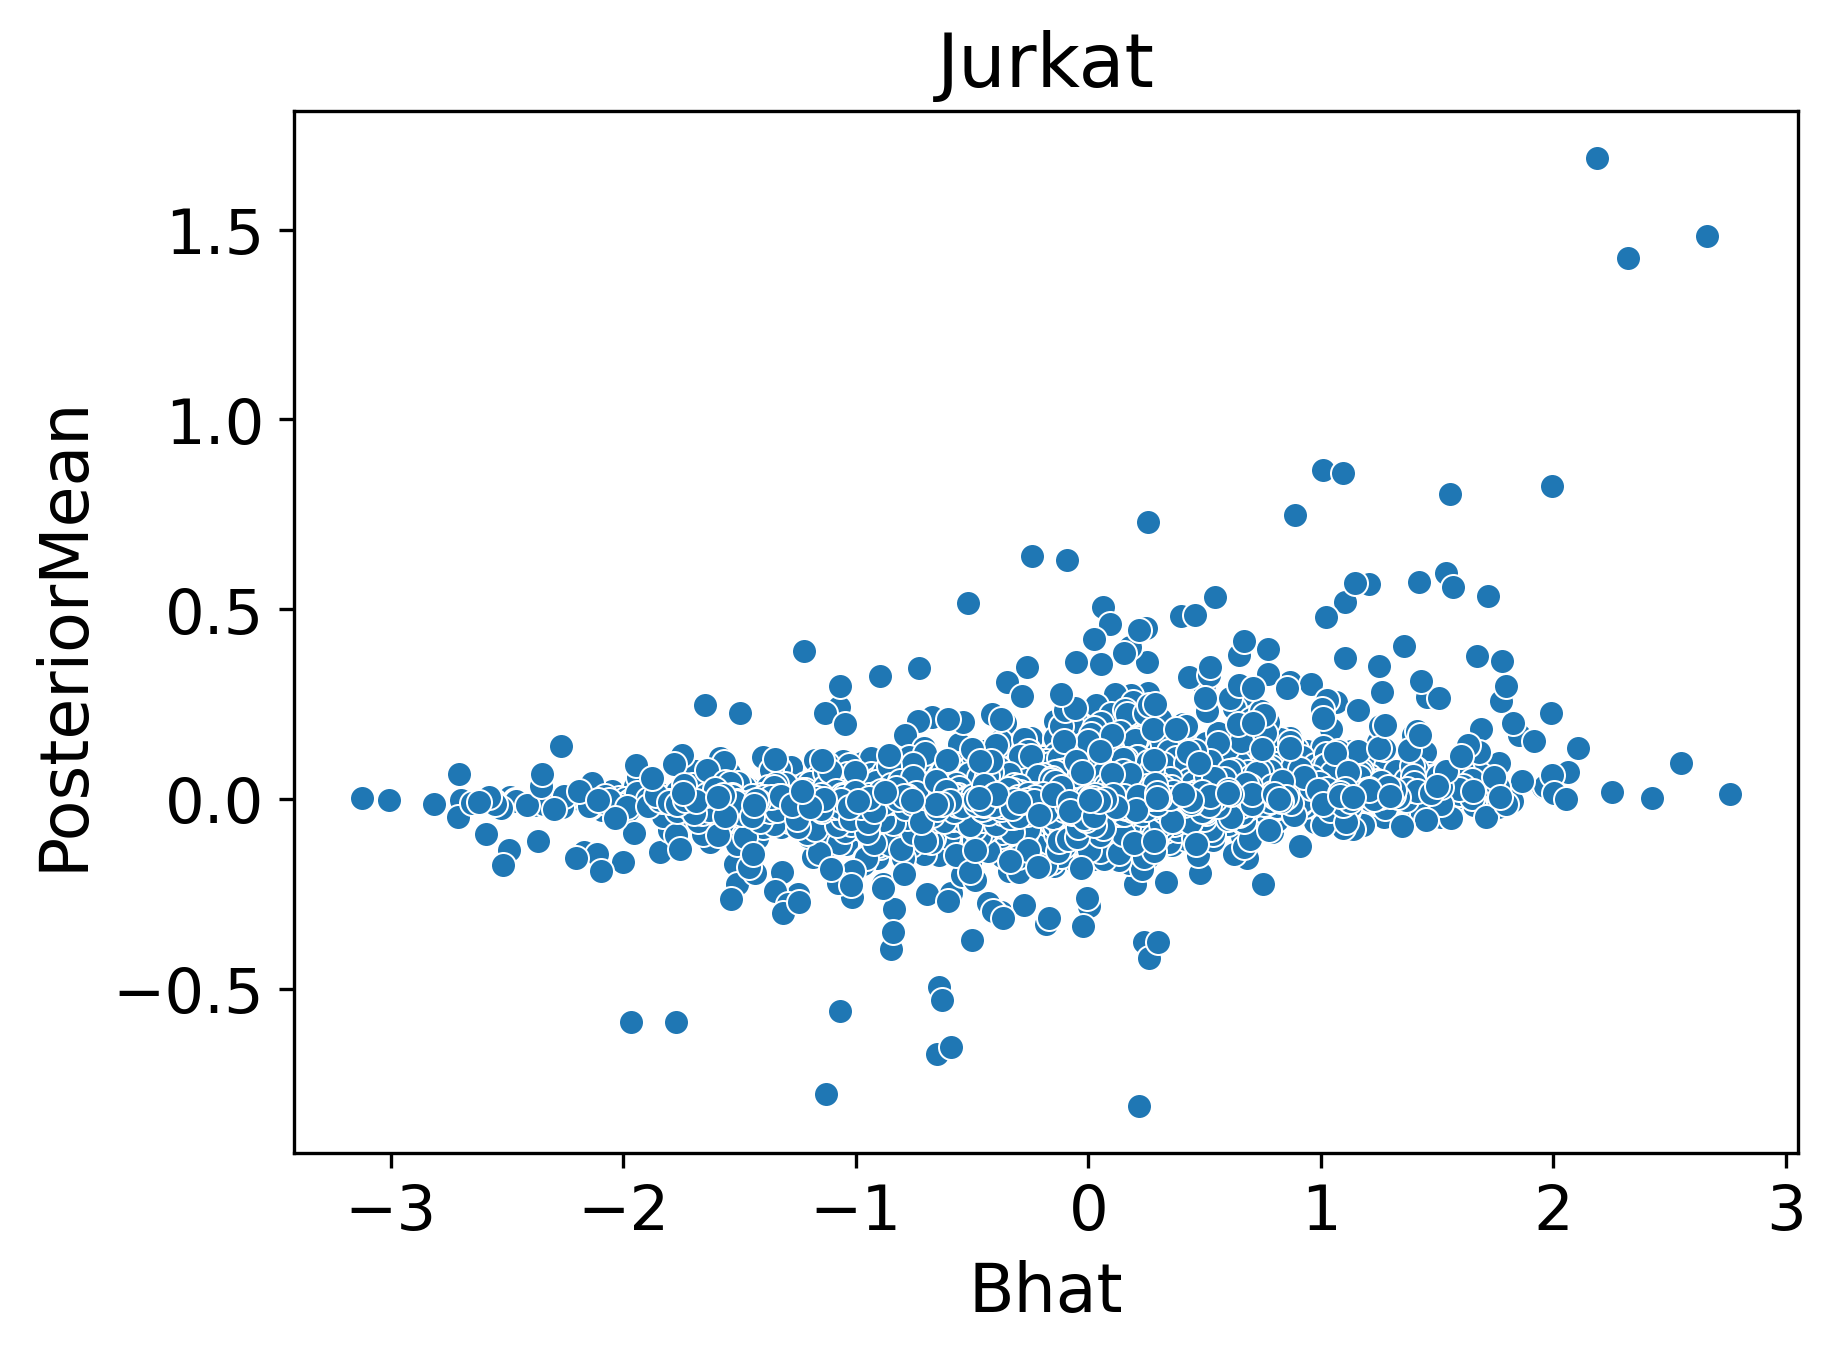

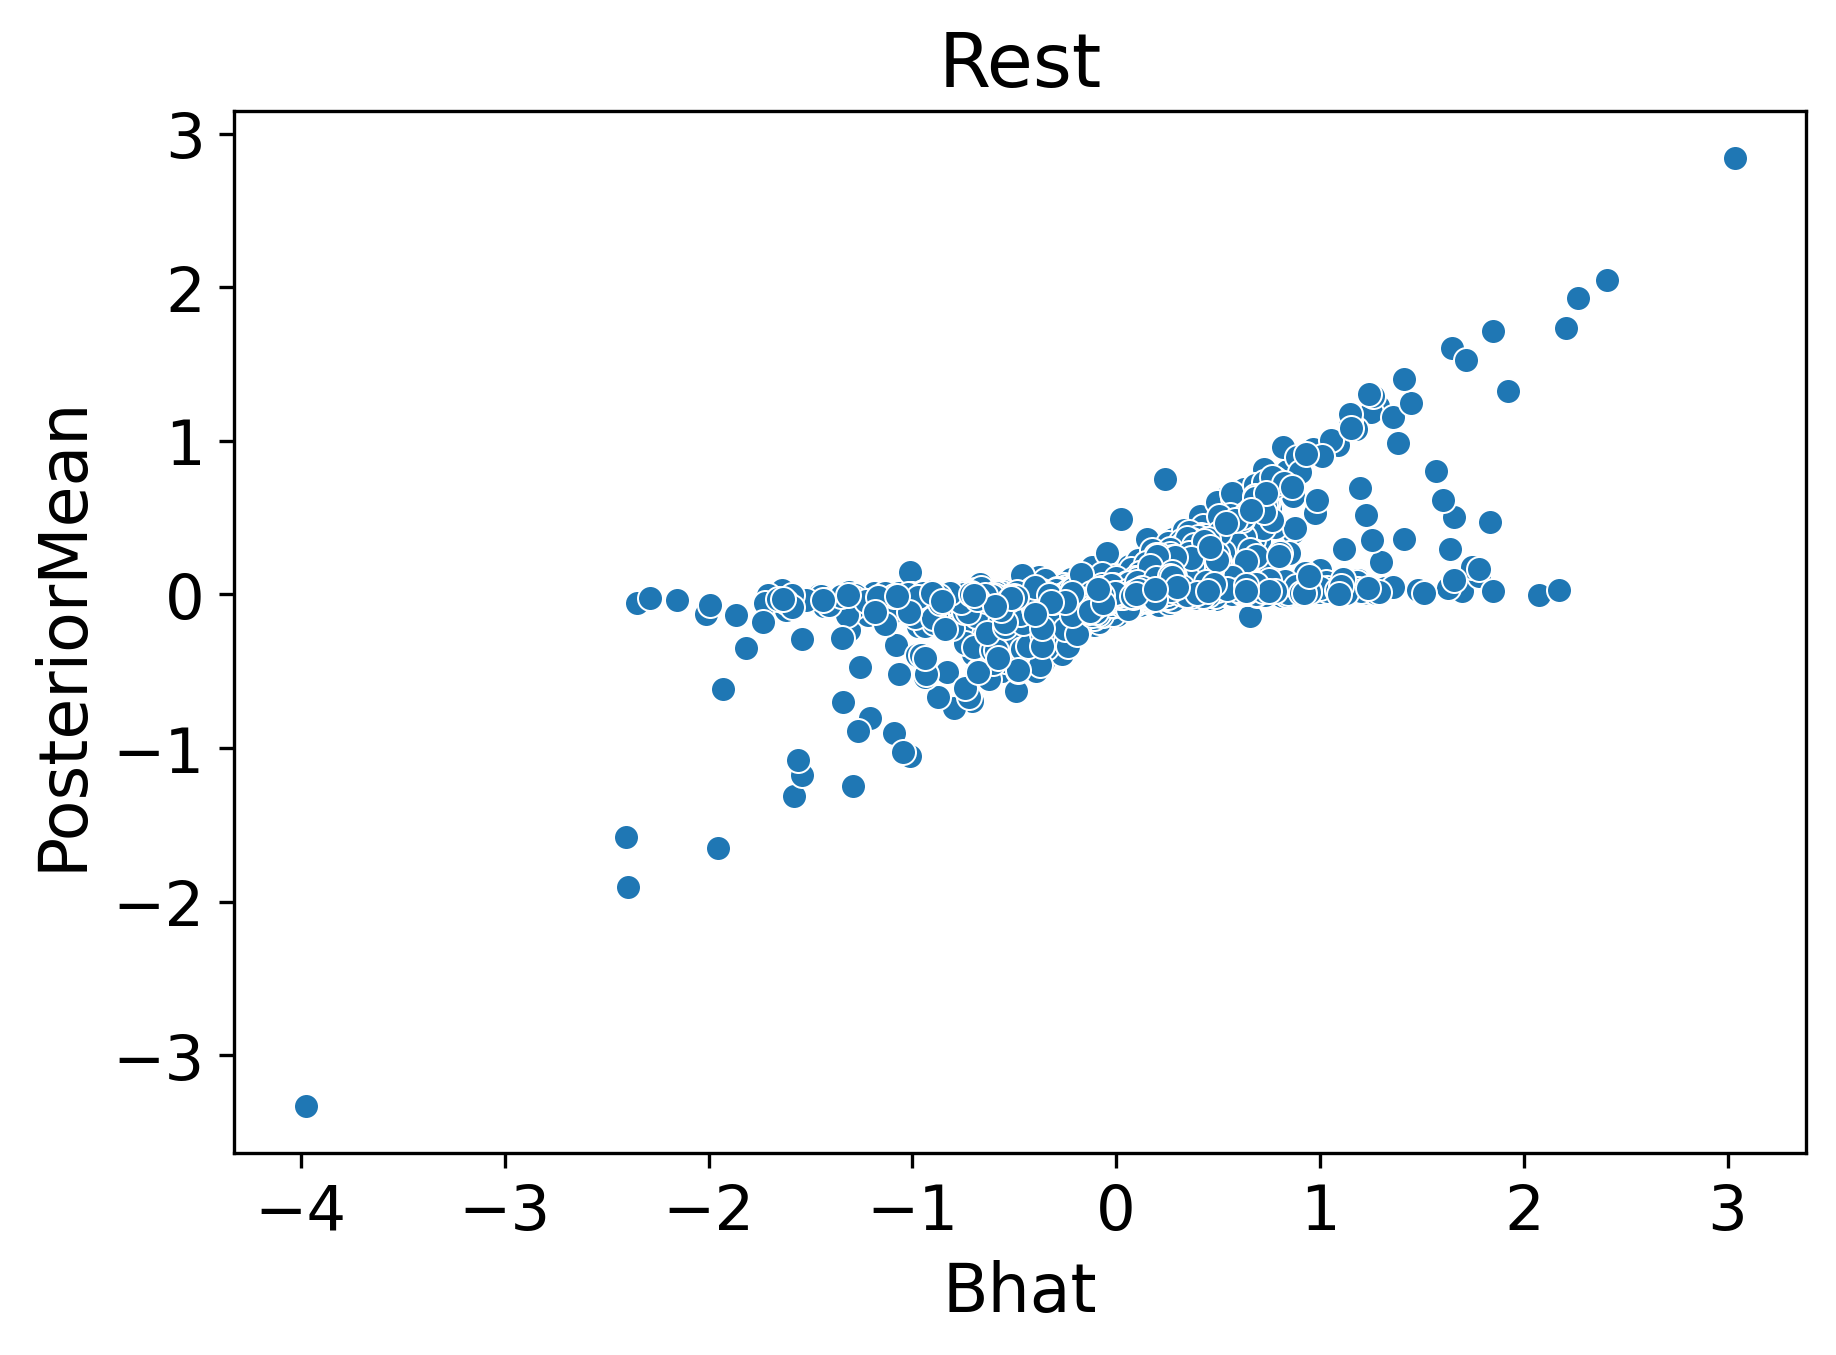

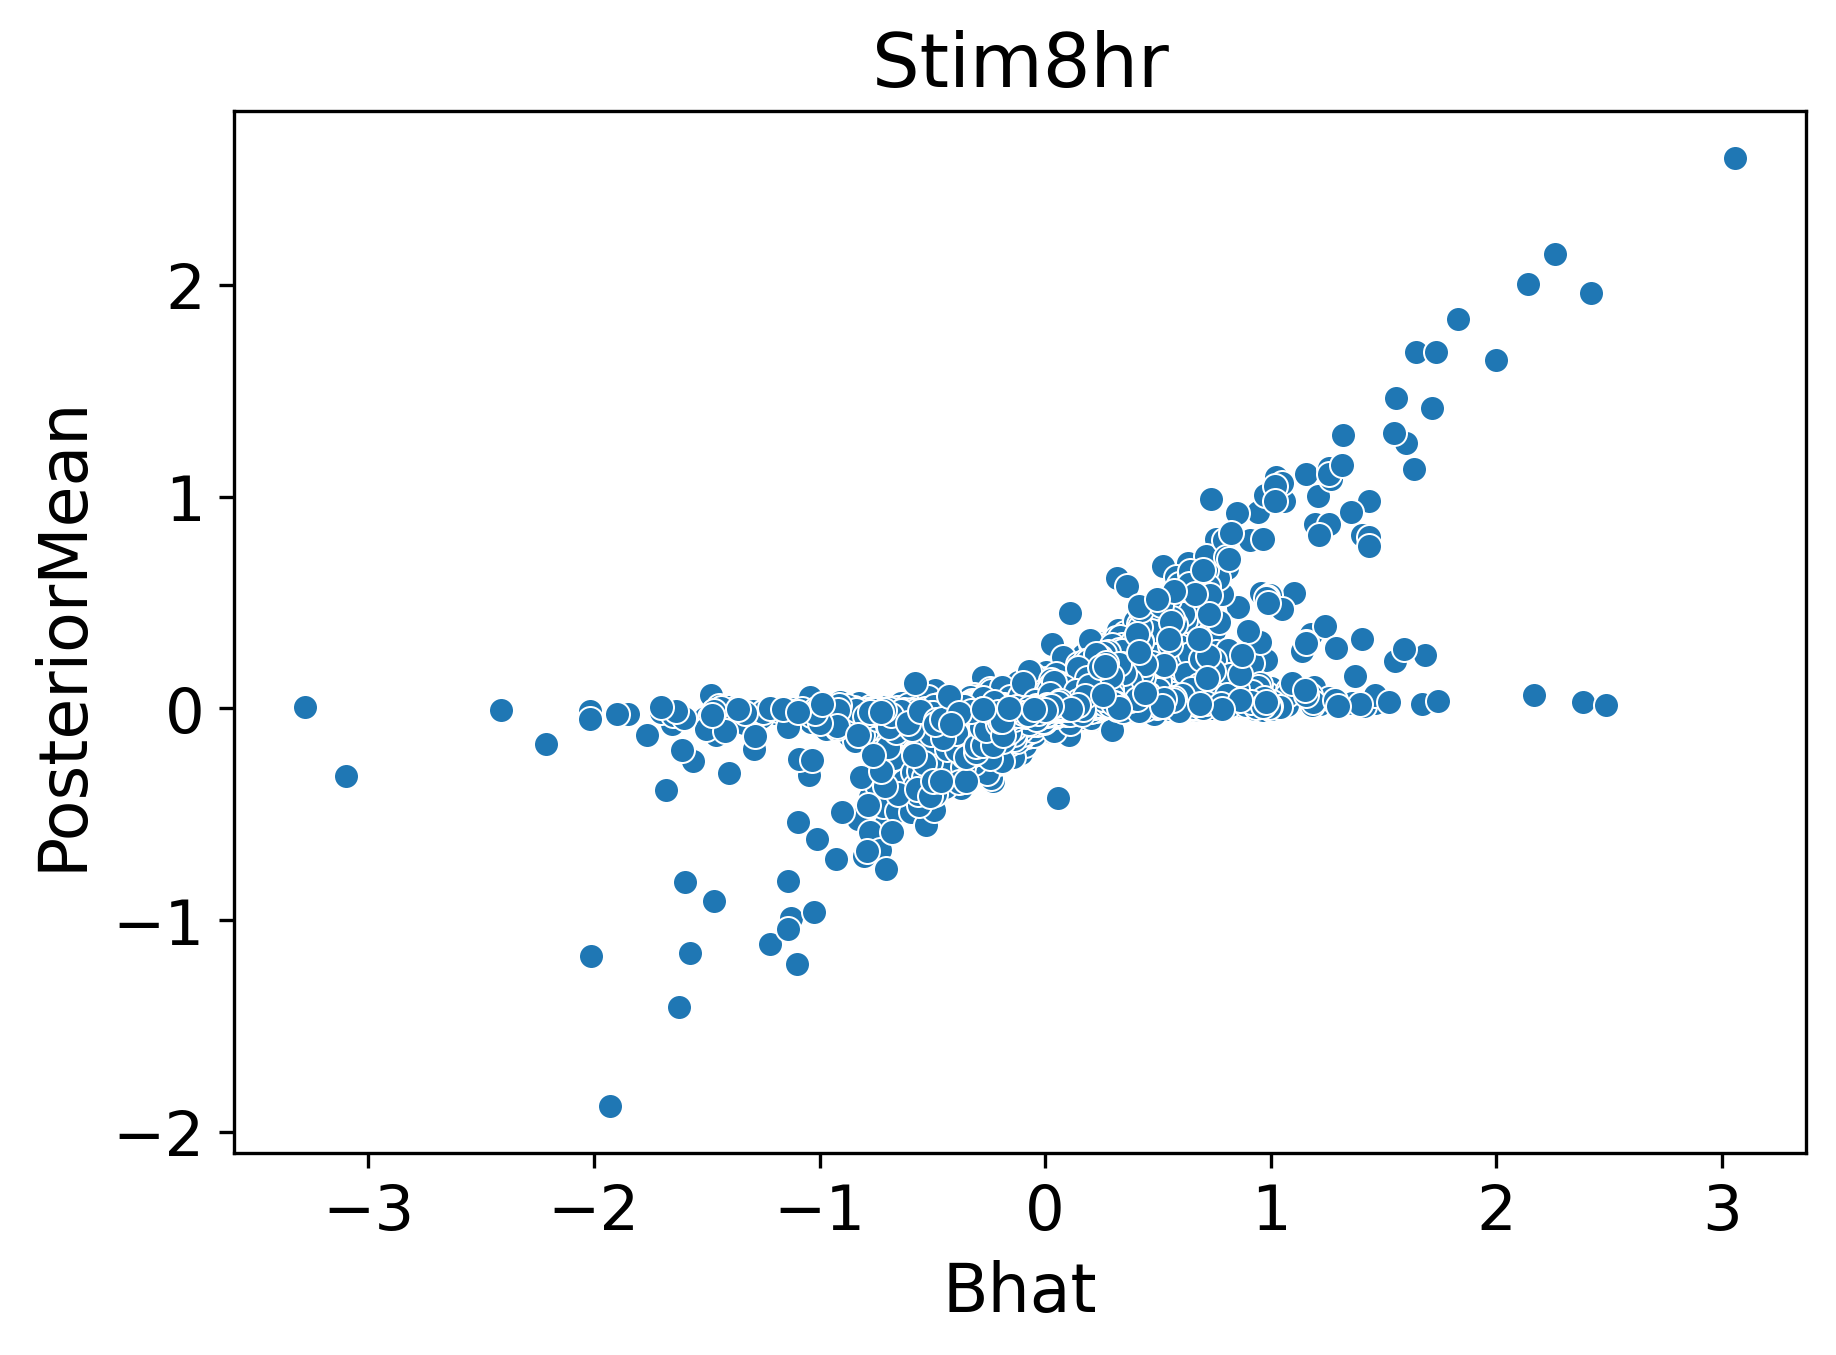

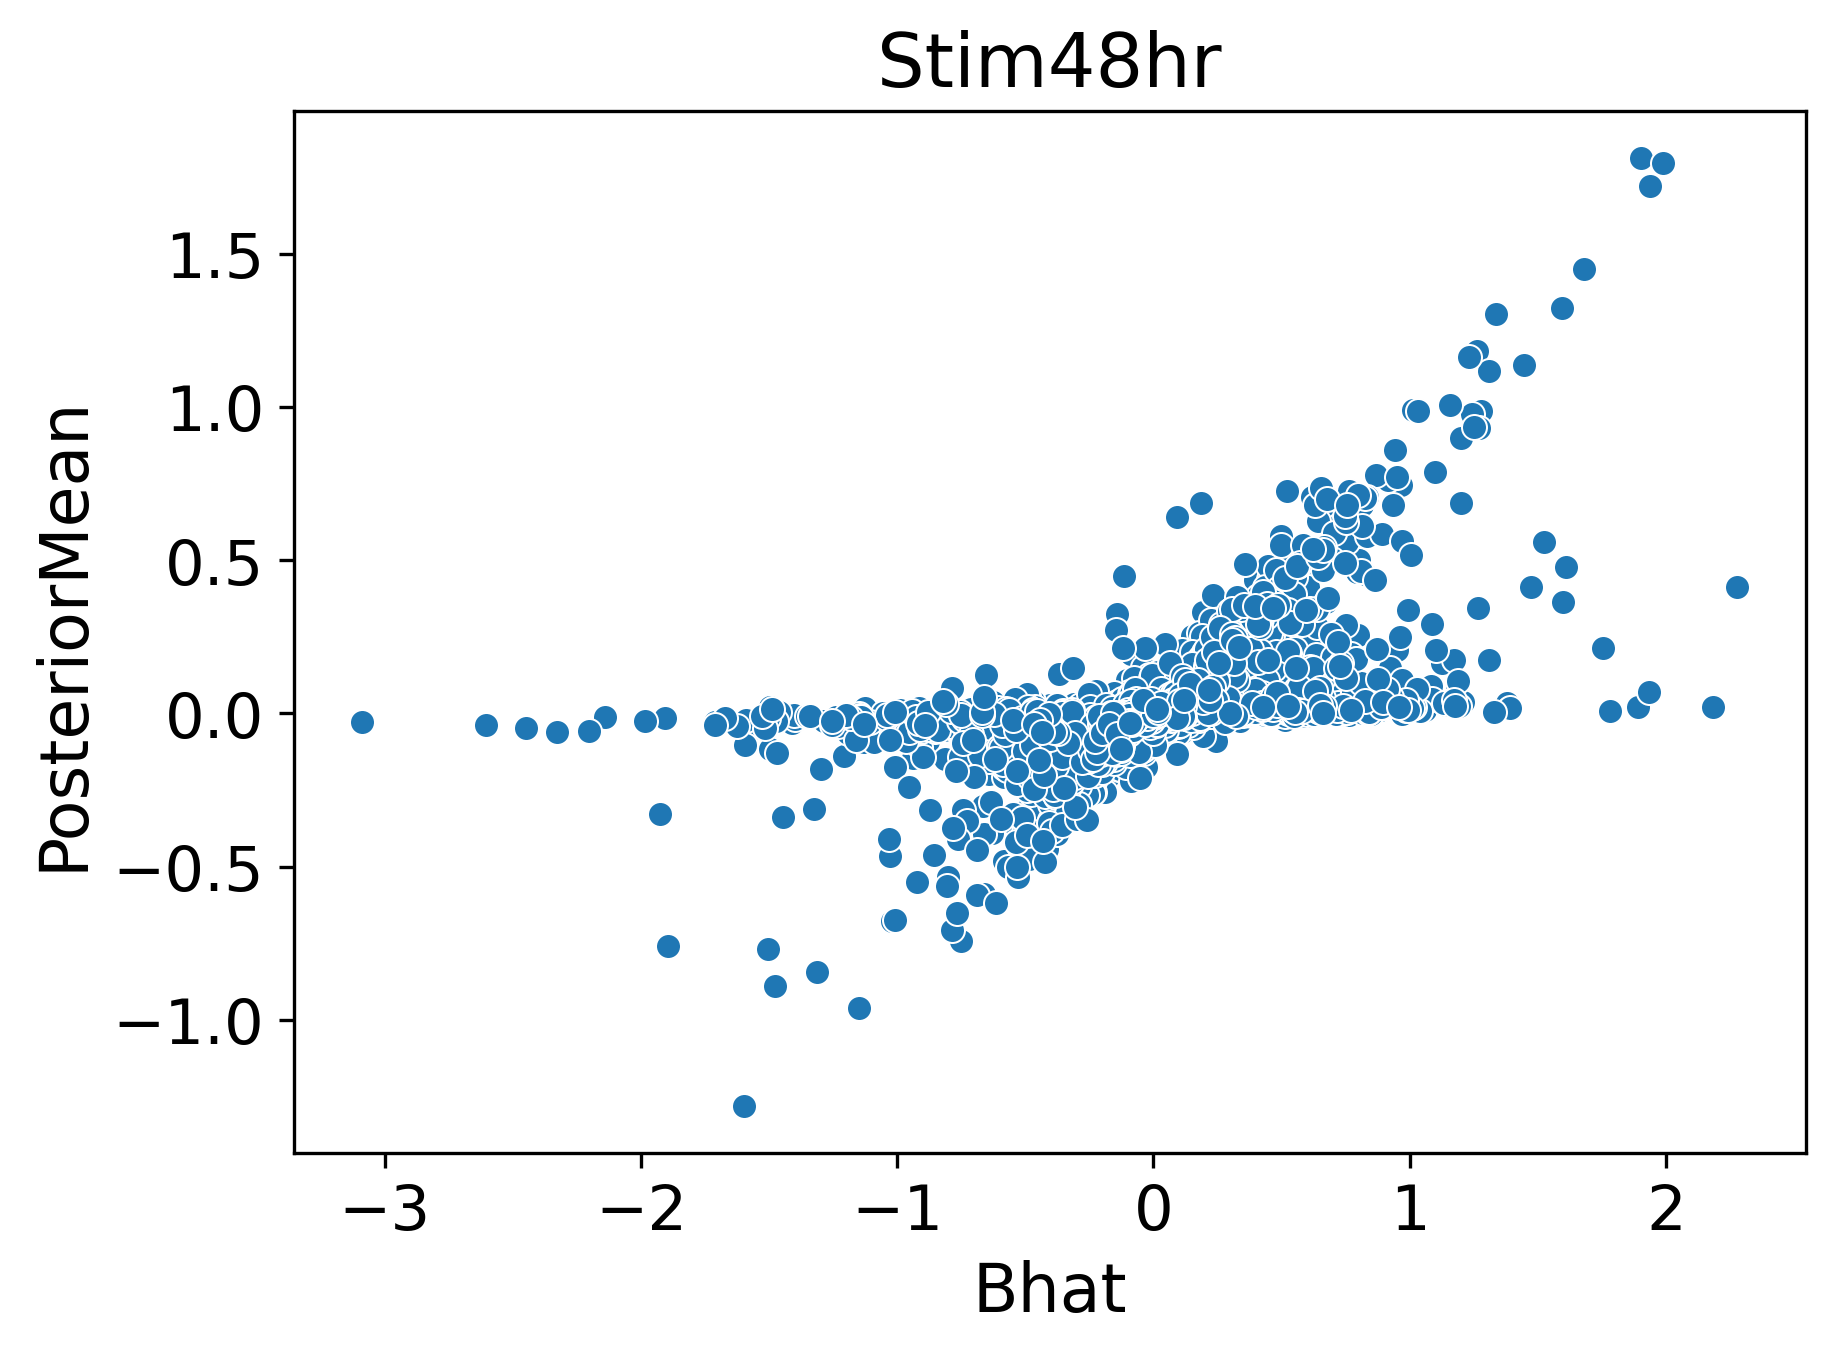

In [9]:
for ct in all_res_df['cell_type'].unique():
    sns.scatterplot(data=all_res_df[all_res_df.cell_type == ct].sample(10000), x='Bhat', y='PosteriorMean')
    plt.title(ct)
    plt.show()

### Visualize overlap in DE genes

In [13]:
signif_res_df = all_res_df[all_res_df['lfsr'] < 0.05]
wide_signif_res_df = signif_res_df.pivot(columns='cell_type', index=['target_contrast', 'gene_name'], values='PosteriorMean')

In [14]:
signif_res_df

,test,Bhat,Shat,PosteriorMean,PosteriorSD,lfsr,target_contrast,gene_name,cell_type
78,COX15_ENSG00000014919,-1.985969,1.024783,-1.199551,0.463893,4.312668e-03,COX15,ENSG00000014919,Jurkat
178,COX15_ENSG00000052841,0.806462,0.410006,0.094715,0.060092,4.958448e-02,COX15,ENSG00000052841,Jurkat
1130,COX15_ENSG00000116539,0.035416,0.305181,0.093740,0.060839,4.948491e-02,COX15,ENSG00000116539,Jurkat
1438,COX15_ENSG00000126522,-1.406280,1.201410,-0.137751,0.095757,4.903297e-02,COX15,ENSG00000126522,Jurkat
1481,COX15_ENSG00000128585,1.059384,0.341340,0.092095,0.051438,2.586417e-02,COX15,ENSG00000128585,Jurkat
...,...,...,...,...,...,...,...,...,...
136445,ZFC3H1_ENSG00000253719,0.494076,0.101441,0.514743,0.096880,5.829417e-08,ZFC3H1,ENSG00000253719,Stim48hr
136464,ZFC3H1_ENSG00000275066,-0.238702,0.099157,-0.161593,0.077224,2.032922e-02,ZFC3H1,ENSG00000275066,Stim48hr
136468,ZFC3H1_ENSG00000277161,0.912802,0.159203,0.988407,0.142241,1.590940e-10,ZFC3H1,ENSG00000277161,Stim48hr
136471,ZFC3H1_ENSG00000278023,0.924760,0.149567,0.981959,0.143094,1.635752e-11,ZFC3H1,ENSG00000278023,Stim48hr


/tmp/ipykernel_1524394/3617903297.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)


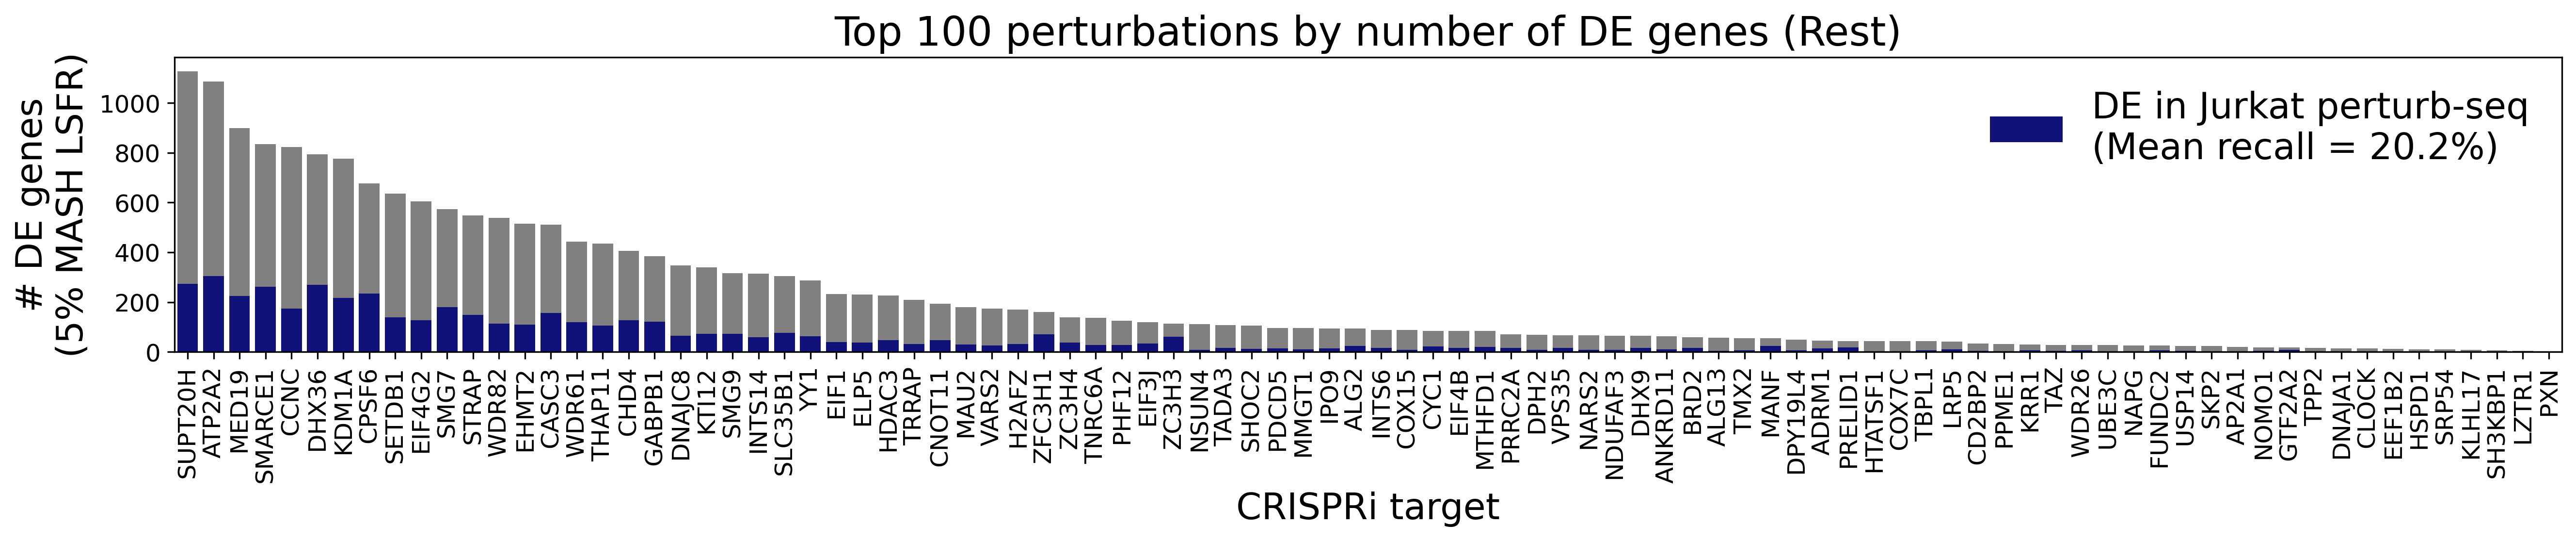

/tmp/ipykernel_1524394/3617903297.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)


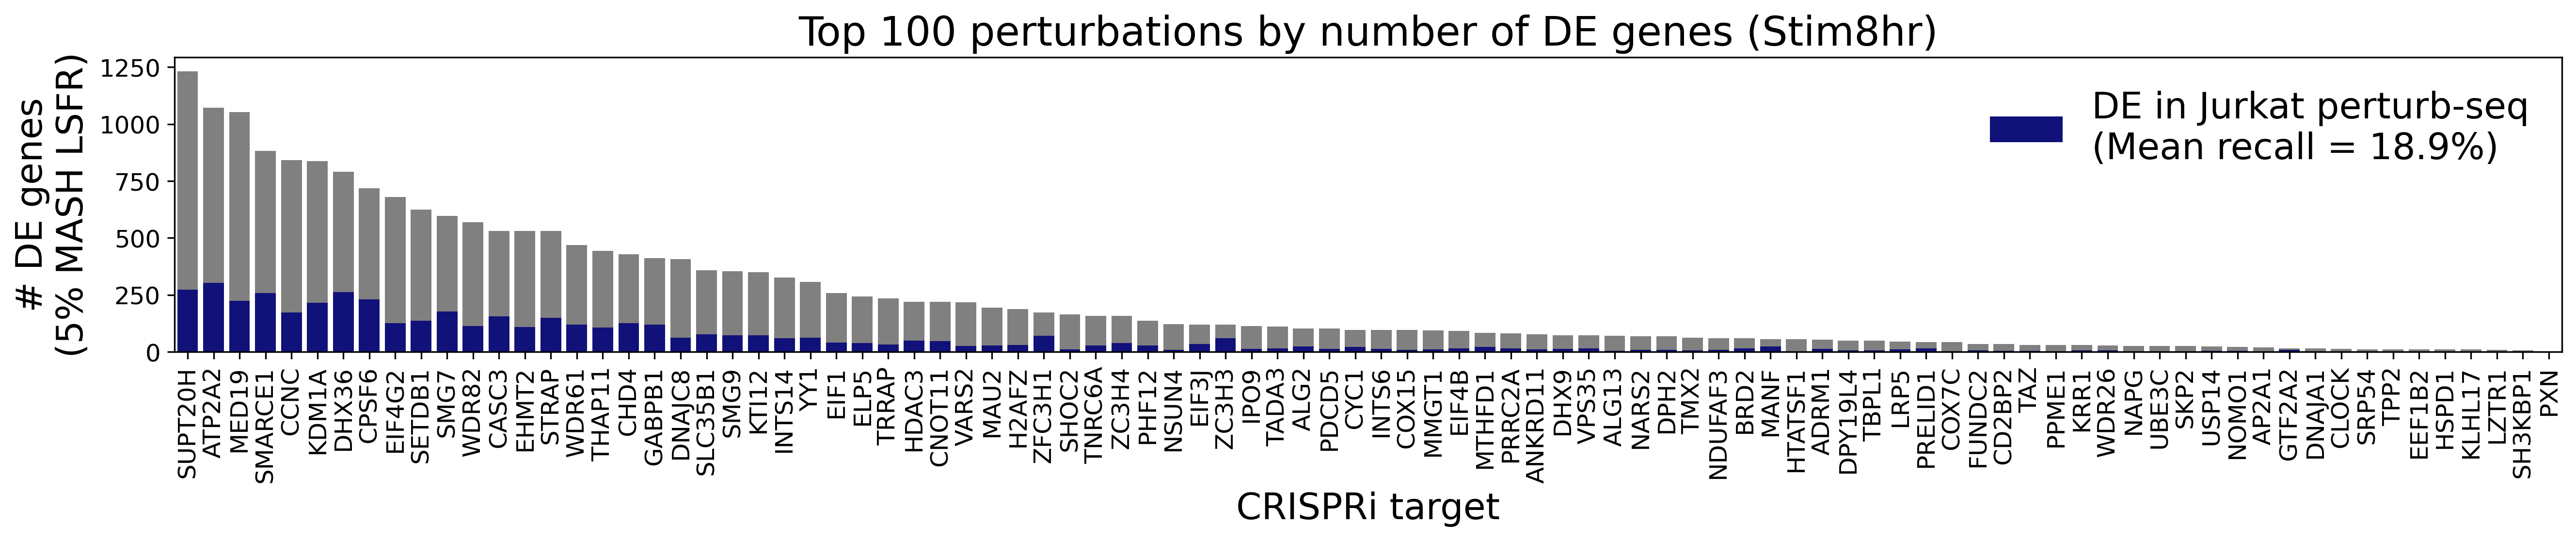

/tmp/ipykernel_1524394/3617903297.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)


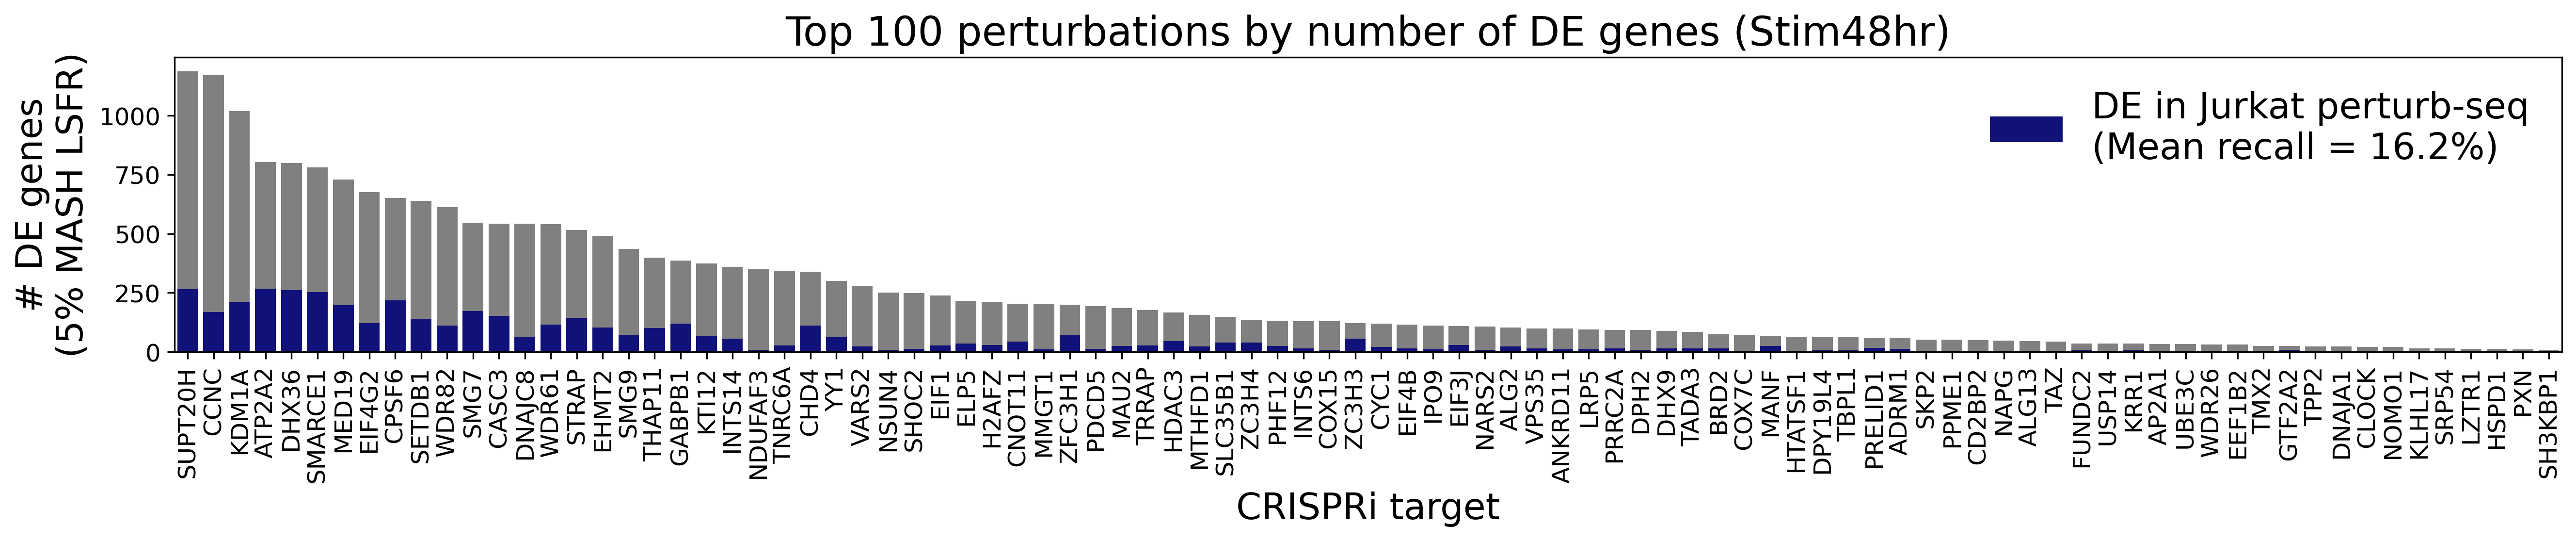

In [15]:
jurkat_de_compare_dict = {}
for c in ['Rest', 'Stim8hr', 'Stim48hr']:
    signif_df = (wide_signif_res_df[['Jurkat', c]]
        .groupby('target_contrast')
        .apply(lambda x: pd.Series({
            'Jurkat_repl': ((~x['Jurkat'].isna()) & (~x[c].isna())).sum(),
            'n_signif': (~x[c].isna()).sum()
        })))
    signif_df = signif_df.sort_values('n_signif', ascending=False)

    # Take top 100 perturbations
    pl_signif_df = signif_df.head(100)

    # Create single figure
    fig, ax = plt.subplots(figsize=(18, 4))

    # Plot bars
    sns.barplot(data=pl_signif_df, x='target_contrast', y='n_signif', ax=ax, color='grey')
    sns.barplot(data=pl_signif_df, x='target_contrast', y='Jurkat_repl', ax=ax, color='darkblue', 
                label=f'DE in Jurkat perturb-seq\n(Mean recall = {np.round(np.mean(signif_df["Jurkat_repl"]/signif_df["n_signif"]) * 100, 1)}%)')

    # Customize plot
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)
    ax.set_ylabel('# DE genes\n(5% MASH LSFR)', fontsize=18)
    ax.set_xlabel('CRISPRi target', fontsize=18)
    ax.tick_params(axis='y', labelsize=12)
    ax.legend(frameon=False, fontsize=18)

    plt.title(f'Top 100 perturbations by number of DE genes ({c})', fontsize=20)
    plt.tight_layout()
    plt.savefig(f'./results/recall_top100_barplot.{c}.png')
    plt.savefig(f'./results/recall_top100_barplot.{c}.pdf')
    plt.show()

In [16]:
# Load K562 MASH results for comparison
k562_res_df = pd.read_parquet('/mnt/oak/users/emma/data/GWT/CD4i_final/MASH_comparison_results.parquet')
k562_split = k562_res_df.test.str.split("_", expand=True).rename(columns={0: "target_contrast", 1: "gene_name"})
k562_res_df = pd.concat([k562_res_df, k562_split], axis=1)
k562_res_df['cell_type'] = np.where(k562_res_df['index'] == 'log_fc', 'K562', k562_res_df['index'])
k562_res_df = k562_res_df.drop(['model_key', 'index'], axis=1)

k562_signif_df = k562_res_df[k562_res_df['lfsr'] < 0.05]
wide_signif_k562 = k562_signif_df.pivot(columns='cell_type', index=['target_contrast', 'gene_name'], values='PosteriorMean')

In [ ]:
# offtargets = pd.read_csv('../../5_sgRNA_annotation/results/putative_offtarget_hits.csv')
# import scipy.stats as stats

# # sns.stripplot(data=pl_df, y='pearson_r', x='group')
# # sns.boxplot(data=pl_df, y='pearson_r', x='group')

# # Test if the difference between groups is significant
# grp1_vals = pl_df[pl_df['group'] == 'offtarget pairs']['pearson_r']
# grp2_vals = pl_df[pl_df['group'] == 'shuffled pairs']['pearson_r']
# # Use Mann-Whitney U test (nonparametric, since pearson_r may not be normal)
# stat, pval = stats.ttest_ind([grp1_vals.iloc[0]], grp2_vals, alternative='two-sided')
# print(f"Mann-Whitney U test p-value for difference in groups: {pval:.3e}")
# correlation_results_df.sort_values("pearson_r")
# p = ('RNF19B', 'RRAGC')
# pl_df = k562_res_df[(k562_res_df['target_contrast'].isin(p)) & (k562_res_df.cell_type == 'K562')]
# pl_df = pl_df.pivot(index = 'gene_name', columns='target_contrast', values='Bhat')
# pl_df = pl_df[~pl_df.index.isin(p)]

# from scipy.stats import pearsonr

# # Drop NaNs for a fair comparison
# non_nan_idx = pl_df[[p[0], p[1]]].dropna().index
# x = pl_df.loc[non_nan_idx, p[0]]
# y = pl_df.loc[non_nan_idx, p[1]]

# # Calculate Pearson correlation and p-value
# r, pval = pearsonr(x, y)

# fig, ax = plt.subplots(figsize=(8,6))
# sc = ax.scatter(x, y, s=60, c='dodgerblue', edgecolor='k', alpha=0.7)
# ax.plot([x.min(), x.max()], [x.min(), x.max()], 'r--', linewidth=1, label='y=x')
# ax.set_xlabel(f'{p[0]} Bhat', fontsize=14)
# ax.set_ylabel(f'{p[1]} Bhat', fontsize=14)

# title_str = f'{p[0]} vs {p[1]}: r={r:.2f}, p={pval:.2g}'
# ax.set_title(title_str, fontsize=16, fontweight='bold')
# ax.grid(True, linestyle='--', alpha=0.3)
# ax.legend(loc='upper left')
# plt.tight_layout()
# plt.show()

# only_k562_res_df = k562_res_df[(k562_res_df.cell_type == 'K562')]
# k562_perturbs = k562_res_df.target_contrast.unique().tolist()

# pairs = [(r['target'], r['downreg_gene']) for i,r in offtargets.iterrows()]
# import random

# firsts = [p[0] for p in pairs]
# shuffled_pairs = []

# for f in firsts:
#     # Sample 3 random perturbations from k562_perturbs, making sure they are not the same as f
#     valid_choices = [x for x in k562_perturbs if x != f]
#     sampled = random.sample(valid_choices, 3) if len(valid_choices) >= 3 else valid_choices
#     for s in sampled:
#         shuffled_pairs.append((f, s))

In [ ]:
# correlation_results = []

# for p in pairs:
#     if all([g in k562_perturbs for g in p]):
#         pl_df = only_k562_res_df[(only_k562_res_df['target_contrast'].isin(p))]
#         pl_df = pl_df.pivot(index='gene_name', columns='target_contrast', values='Bhat')
#         pl_df = pl_df[~pl_df.index.isin(p)]

#         # Drop NaNs for a fair comparison
#         non_nan_idx = pl_df[[p[0], p[1]]].dropna().index
#         x = pl_df.loc[non_nan_idx, p[0]]
#         y = pl_df.loc[non_nan_idx, p[1]]

#         # Calculate Pearson correlation and p-value
#         r, pval = pearsonr(x, y)

#         # Save results for each pair
#         correlation_results.append({
#             'perturbation_1': p[0],
#             'perturbation_2': p[1],
#             'pearson_r': r,
#             'pearson_pval': pval,
#             'n_overlap_genes': len(non_nan_idx)
#         })

# correlation_results_df = pd.DataFrame(correlation_results)

# correlation_results = []

# for p in shuffled_pairs:
#     if all([g in k562_perturbs for g in p]):
#         pl_df = only_k562_res_df[(only_k562_res_df['target_contrast'].isin(p))]
#         pl_df = pl_df.pivot(index='gene_name', columns='target_contrast', values='Bhat')
#         pl_df = pl_df[~pl_df.index.isin(p)]

#         # Drop NaNs for a fair comparison
#         non_nan_idx = pl_df[[p[0], p[1]]].dropna().index
#         x = pl_df.loc[non_nan_idx, p[0]]
#         y = pl_df.loc[non_nan_idx, p[1]]

#         # Calculate Pearson correlation and p-value
#         r, pval = pearsonr(x, y)

#         # Save results for each pair
#         correlation_results.append({
#             'perturbation_1': p[0],
#             'perturbation_2': p[1],
#             'pearson_r': r,
#             'pearson_pval': pval,
#             'n_overlap_genes': len(non_nan_idx)
#         })

# shuffled_correlation_results_df = pd.DataFrame(correlation_results)

In [ ]:
# correlation_results_df['group'] = 'offtarget pairs'
# shuffled_correlation_results_df['group'] = 'shuffled pairs'

# pl_df = pd.concat([correlation_results_df, shuffled_correlation_results_df])

/tmp/ipykernel_1524394/810183883.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


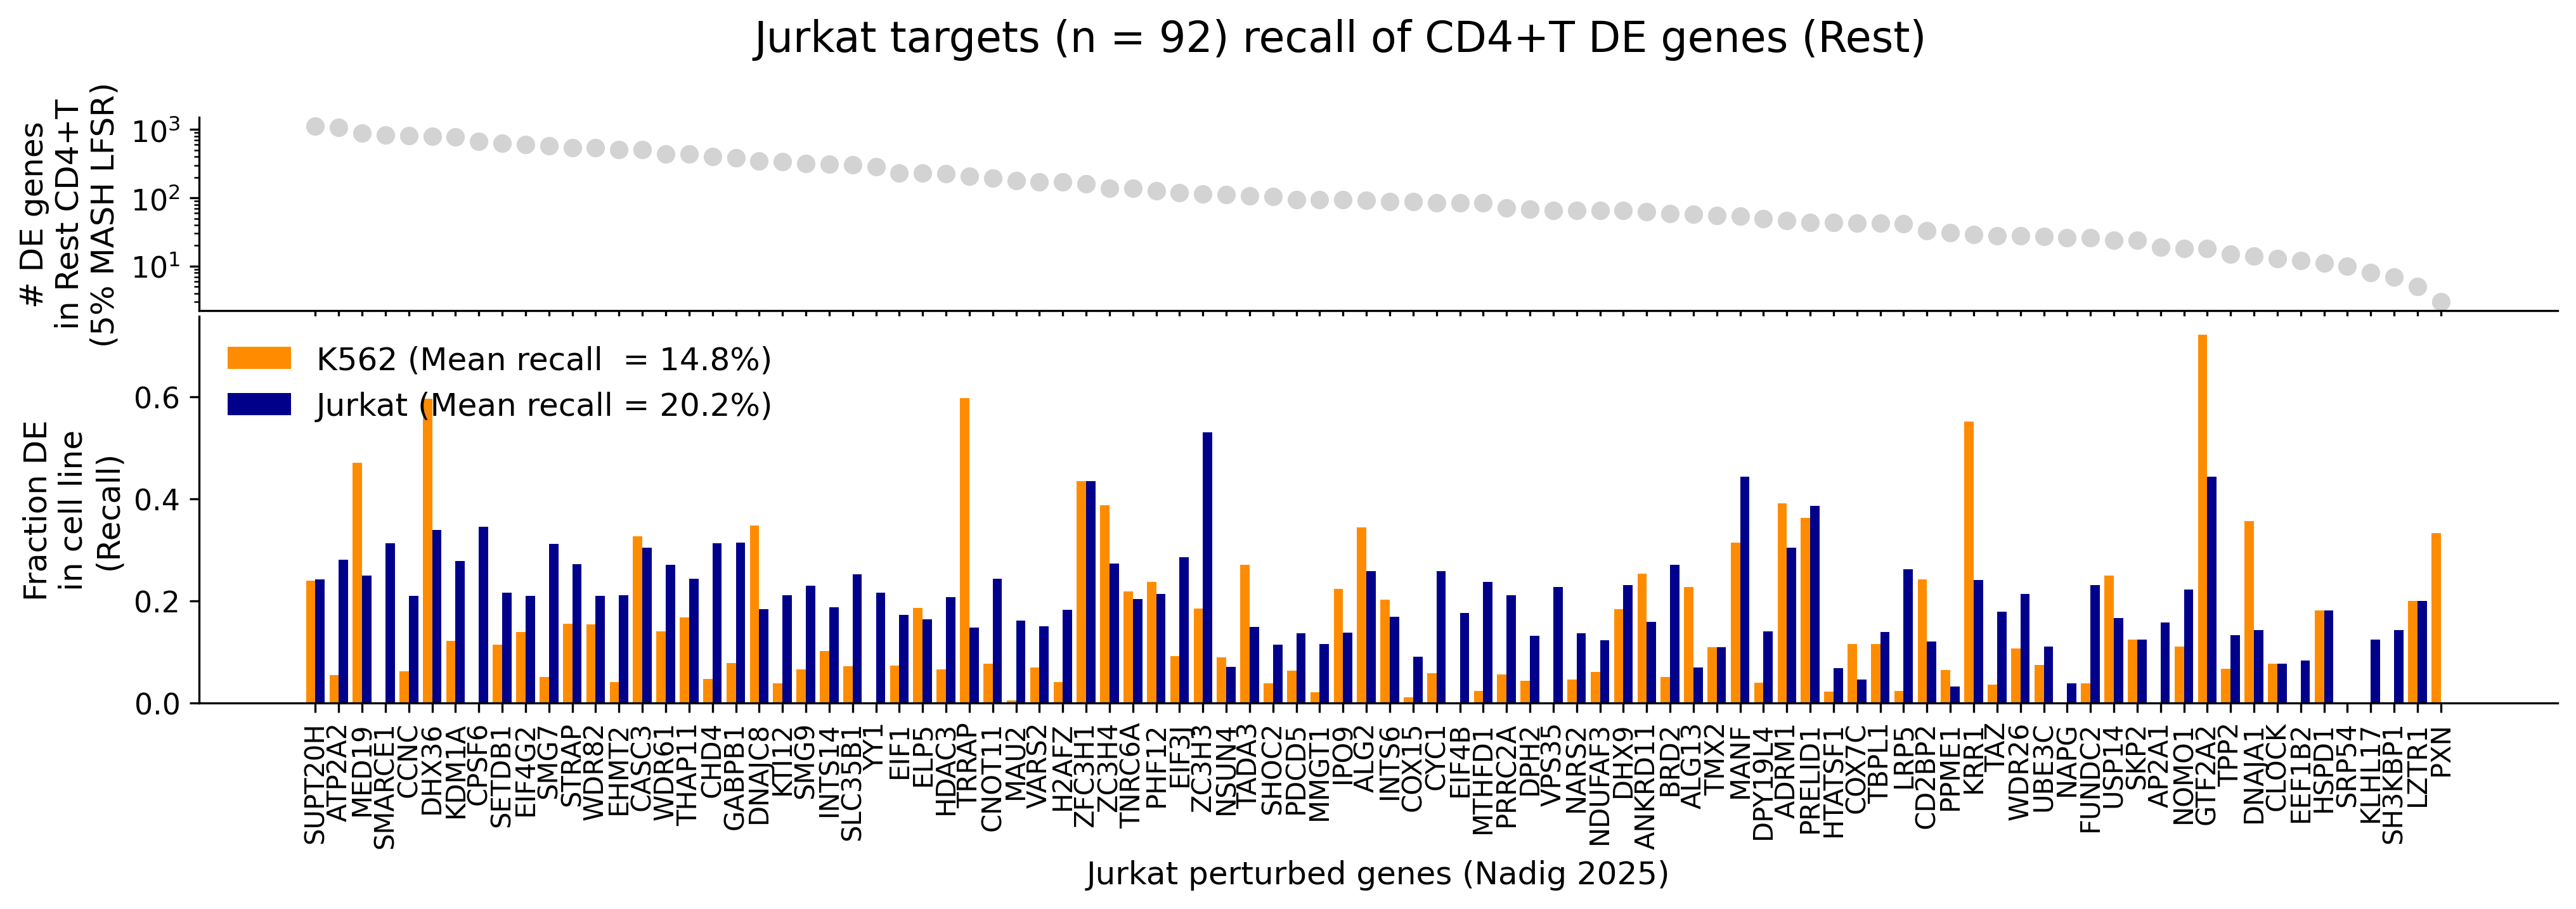

/tmp/ipykernel_1524394/810183883.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


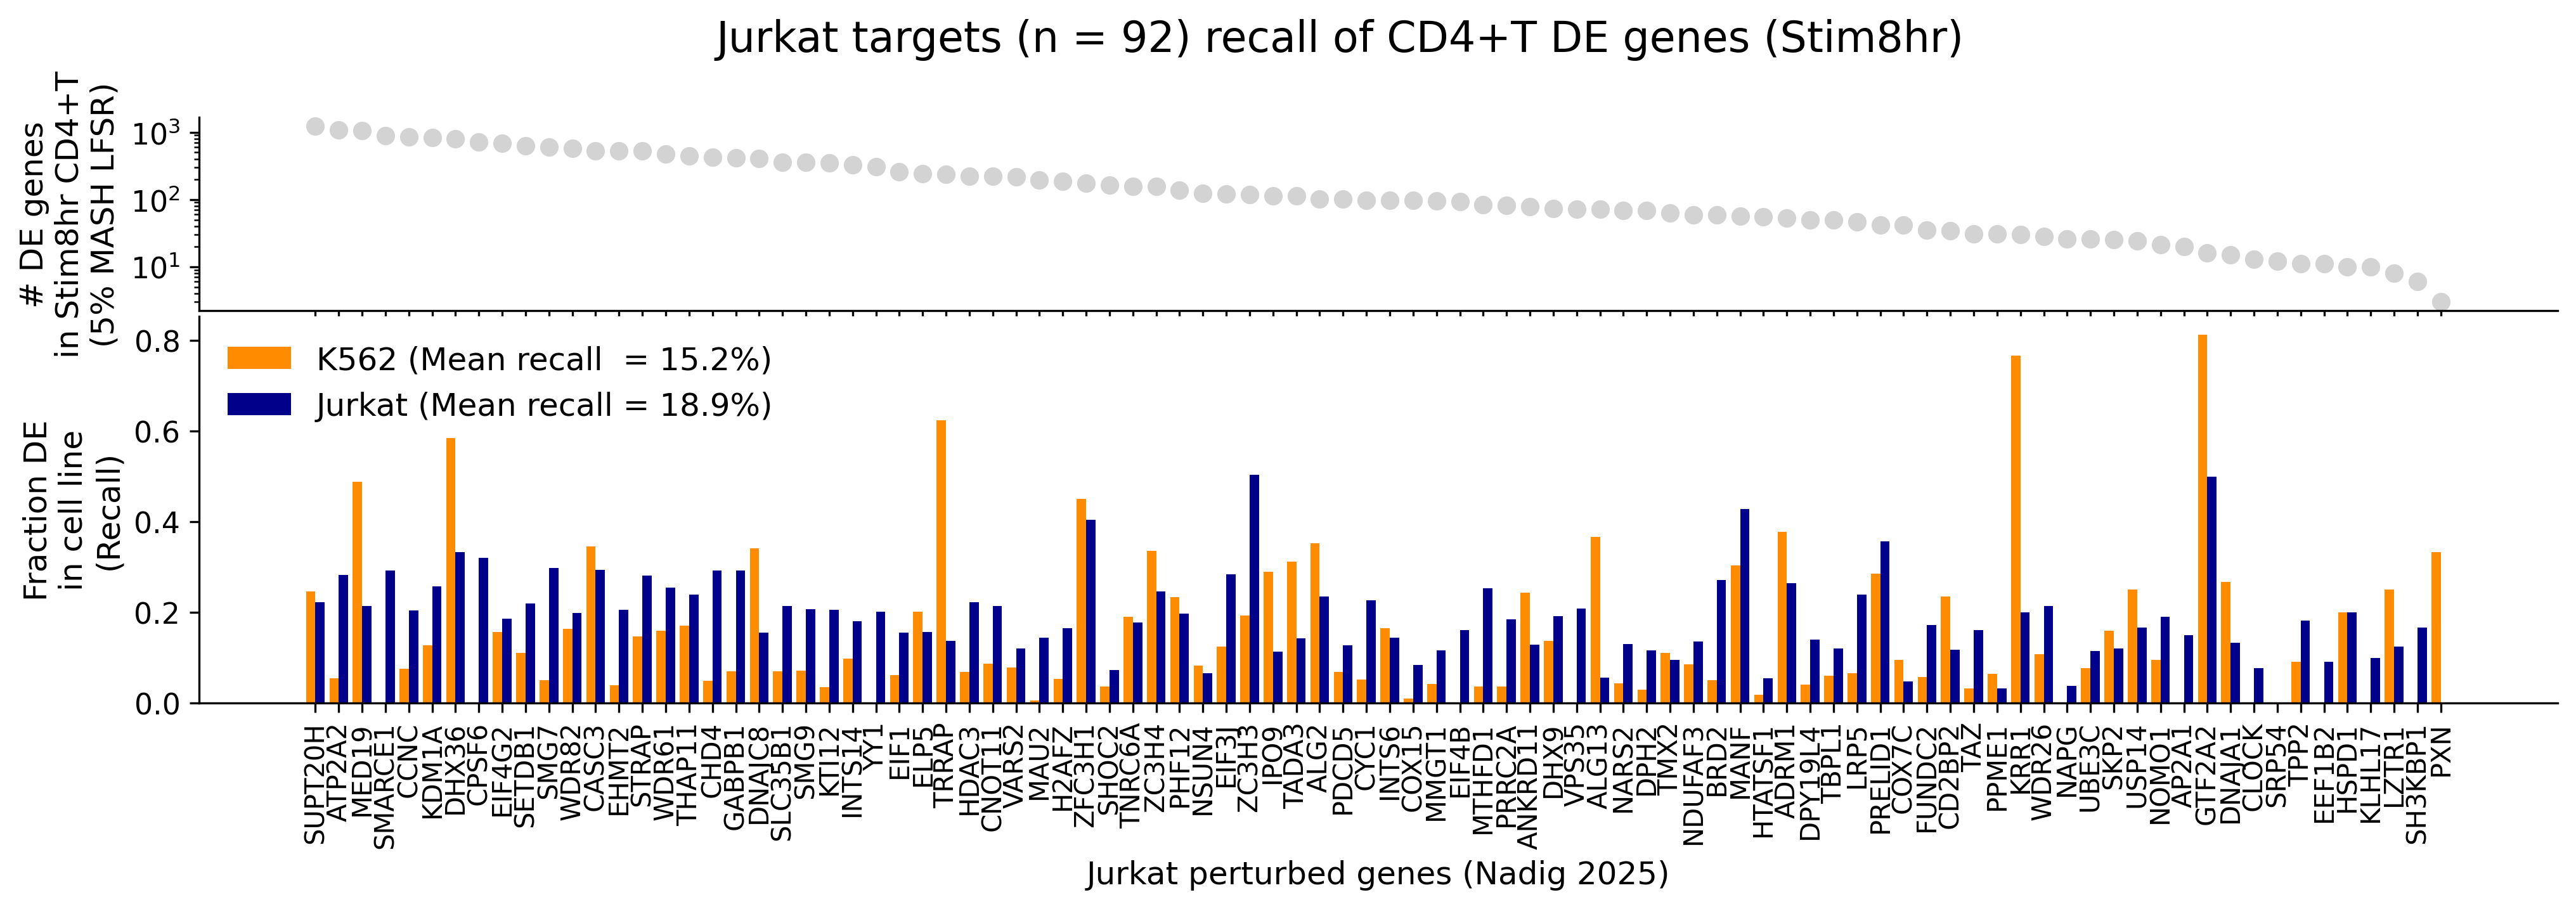

/tmp/ipykernel_1524394/810183883.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


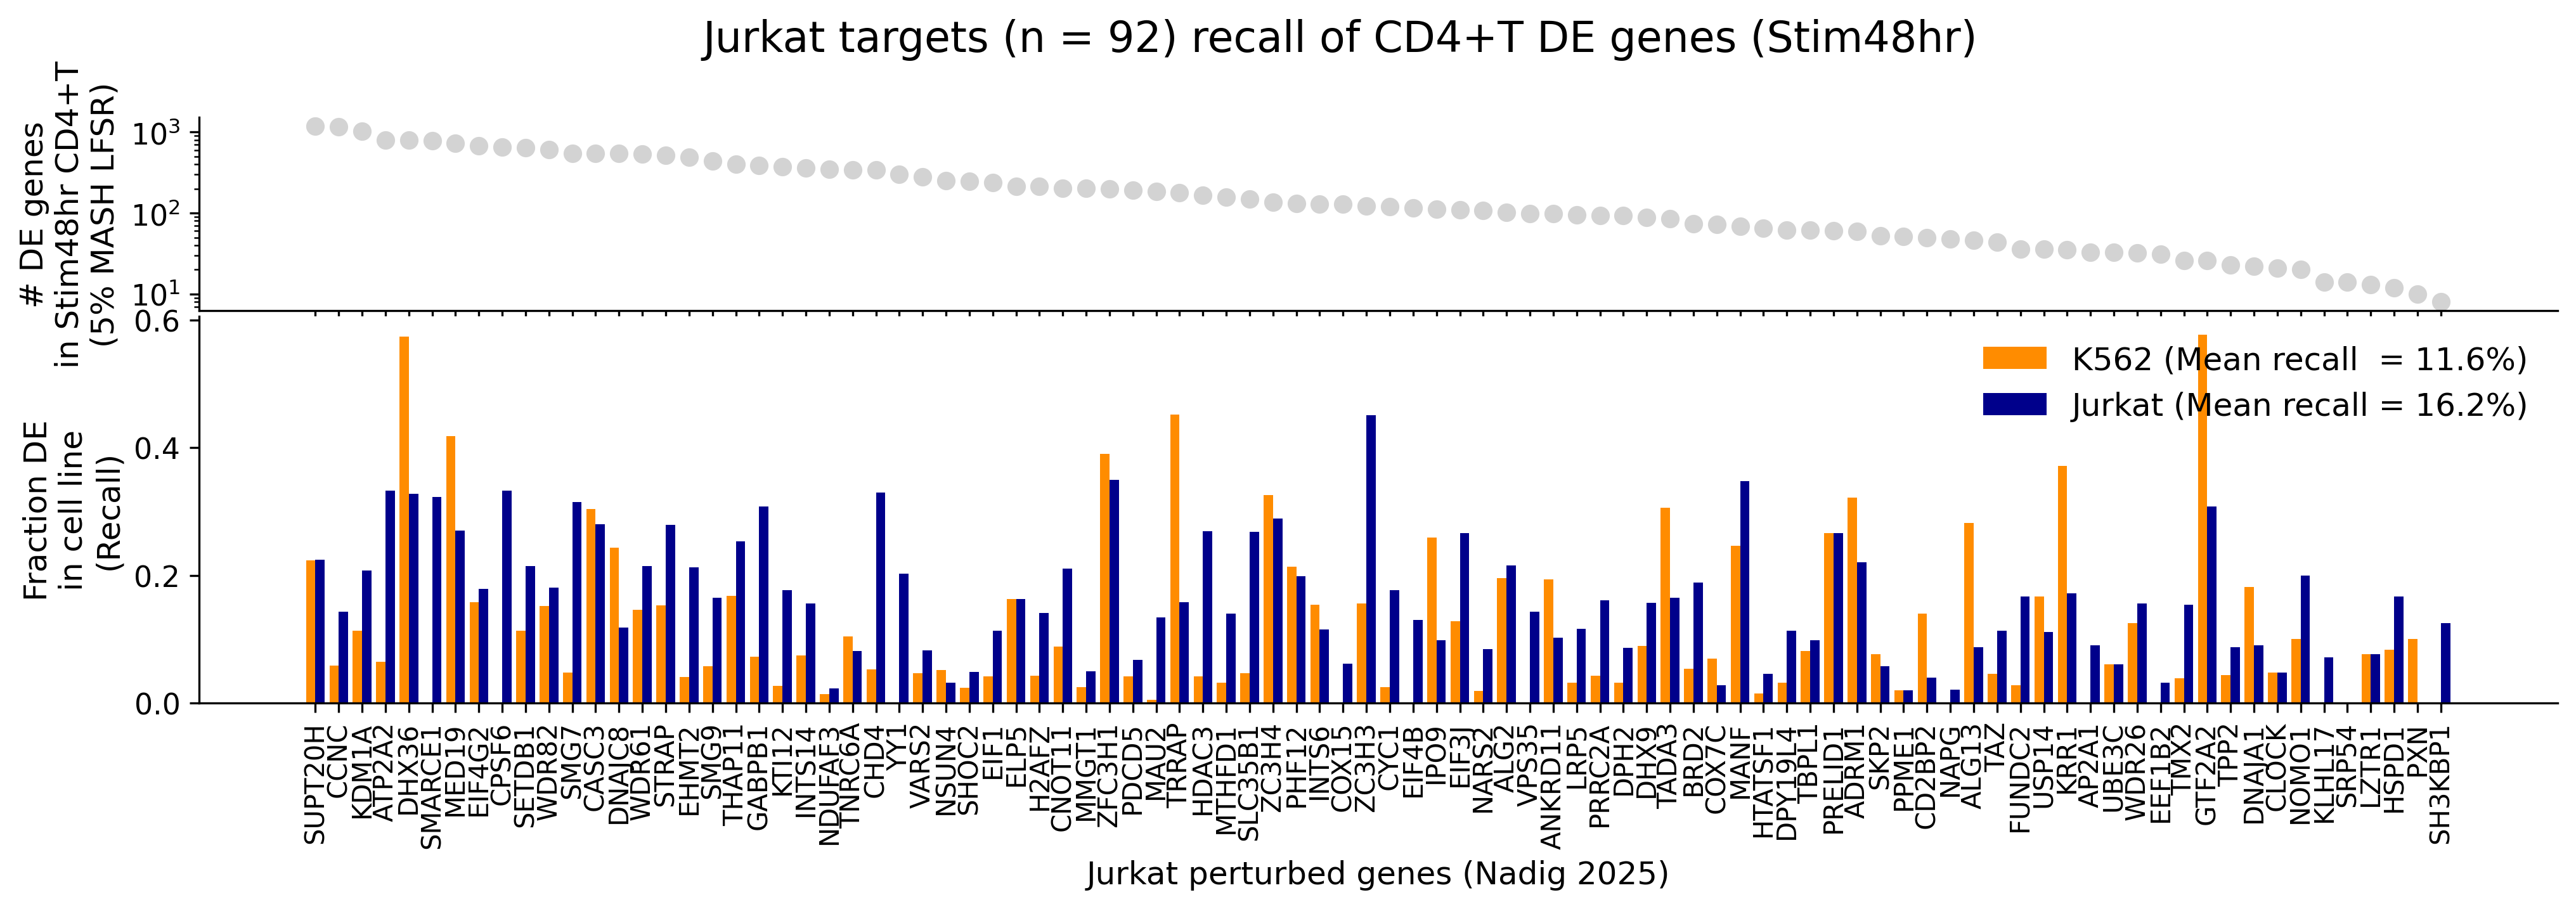

In [111]:

# Jurkat targets (92)
jurkat_targets = wide_signif_res_df.index.get_level_values('target_contrast').unique()

for c in ['Rest', 'Stim8hr', 'Stim48hr']:
    # Recall in CD4+T from Jurkat
    jurkat_recall = (wide_signif_res_df[['Jurkat', c]]
        .groupby('target_contrast')
        .apply(lambda x: pd.Series({
            'Recalled in Jurkat': ((~x['Jurkat'].isna()) & (~x[c].isna())).sum(),
            'DE genes in CD4+T': (~x[c].isna()).sum()
        })))

    # Recall in CD4+T from K562
    if 'K562' in wide_signif_k562.columns and c in wide_signif_k562.columns:
        k562_recall = (wide_signif_k562[['K562', c]]
            .groupby('target_contrast')
            .apply(lambda x: pd.Series({
                'Recalled in K562': ((~x['K562'].isna()) & (~x[c].isna())).sum(),
            })))
    else:
        k562_recall = pd.DataFrame({'Recalled in K562': 0}, index=jurkat_recall.index)

    signif_df = jurkat_recall.join(k562_recall, how='left').fillna(0)
    signif_df = signif_df.loc[signif_df.index.isin(jurkat_targets)]
    signif_df = signif_df.sort_values('DE genes in CD4+T', ascending=False)

    n_de = signif_df['DE genes in CD4+T']
    recall_jurkat = (signif_df['Recalled in Jurkat'] / n_de.replace(0, np.nan)).fillna(0)
    recall_k562 = (signif_df['Recalled in K562'] / n_de.replace(0, np.nan)).fillna(0)

    mean_recall_jurkat = recall_jurkat.mean()
    mean_recall_k562 = recall_k562.mean()

    targets = signif_df.index.tolist()
    x = np.arange(len(targets))

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(16, 4), sharex=True,
                                          gridspec_kw={'height_ratios': [0.5, 1.0], 'hspace': 0.02})

    # Top: number of DE genes in CD4+T (dotplot)
    ax_top.plot(x, n_de.values, 'o', color='lightgrey')
    ax_top.set_ylabel(f'# DE genes\nin {c} CD4+T\n(5% MASH LFSR)', fontsize=12)
    ax_top.tick_params(axis='y', labelsize=11)
    ax_top.set_yscale('log')
    sns.despine(ax=ax_top)


    # Bottom: recall fraction (dodged)
    width = 0.4
    ax_bot.bar(x - width/2, recall_k562.values, width=width, color='darkorange', edgecolor='none',
               label=f'K562 (Mean recall  = {mean_recall_k562*100:.1f}%)')
    ax_bot.bar(x + width/2, recall_jurkat.values, width=width, color='darkblue', edgecolor='none',
               label=f'Jurkat (Mean recall = {mean_recall_jurkat*100:.1f}%)')

    ax_bot.set_xticks(x)
    ax_bot.set_xticklabels(targets, rotation=90, fontsize=10)
    ax_bot.set_ylabel('Fraction DE\nin cell line\n(Recall)', fontsize=12)
    ax_bot.set_xlabel('Jurkat perturbed genes (Nadig 2025)', fontsize=12)
    ax_bot.tick_params(axis='y', labelsize=11)
    ax_bot.legend(frameon=False, fontsize=12)
    sns.despine(ax=ax_bot)

    fig.suptitle(f'Jurkat targets (n = {len(jurkat_targets)}) recall of CD4+T DE genes ({c})', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig(f'./results/recall_barplot_Jurkat_vs_K562.{c}.png', bbox_inches='tight')
    plt.savefig(f'./results/recall_barplot_Jurkat_vs_K562.{c}.pdf', bbox_inches='tight')
    plt.show()

In [60]:
# for c in ['Rest', 'Stim8hr', 'Stim48hr']:
#     # Recall in CD4+T from Jurkat
#     jurkat_recall = (wide_signif_res_df[['Jurkat', c]]
#         .groupby('target_contrast')
#         .apply(lambda x: pd.Series({
#             'Jurkat_repl': ((~x['Jurkat'].isna()) & (~x[c].isna())).sum(),
#             'n_signif': (~x[c].isna()).sum()
#         })))

#     # Recall in CD4+T from K562 (using same CD4+T targets/genes as reference)
#     k562_recall = (wide_signif_k562[['K562', c]]
#         .groupby('target_contrast')
#         .apply(lambda x: pd.Series({
#             'K562_repl': ((~x['K562'].isna()) & (~x[c].isna())).sum(),
#         })))

#     signif_df = jurkat_recall.join(k562_recall, how='left').fillna(0)
#     signif_df = signif_df.sort_values('n_signif', ascending=False)
#     pl_signif_df = signif_df.head(100)

#     mean_recall_jurkat = np.mean(signif_df['Jurkat_repl'] / signif_df['n_signif'].replace(0, np.nan))
#     mean_recall_k562 = np.mean(signif_df['K562_repl'] / signif_df['n_signif'].replace(0, np.nan))

#     fig, ax = plt.subplots(figsize=(18, 4))
#     sns.barplot(data=pl_signif_df, x='target_contrast', y='n_signif', ax=ax, color='lightgrey',
#                 label='DE genes in CD4+T')
#     sns.barplot(data=pl_signif_df, x='target_contrast', y='K562_repl', ax=ax, color='darkorange',
#                 label=f'Recalled in K562 (mean = {mean_recall_k562*100:.1f}%)', alpha=0.8)
#     sns.barplot(data=pl_signif_df, x='target_contrast', y='Jurkat_repl', ax=ax, color='darkblue',
#                 label=f'Recalled in Jurkat (mean = {mean_recall_jurkat*100:.1f}%)', alpha=0.8)

#     ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)
#     ax.set_ylabel('# DE genes\n(5% MASH LFSR)', fontsize=18)
#     ax.set_xlabel('CRISPRi target', fontsize=18)
#     ax.tick_params(axis='y', labelsize=12)
#     ax.legend(frameon=False, fontsize=14)

#     plt.title(f'Top 100 perturbations by number of DE genes ({c})', fontsize=20)
#     plt.tight_layout()
#     plt.savefig(f'./results/recall_top100_barplot_Jurkat_vs_K562.{c}.png')
#     plt.savefig(f'./results/recall_top100_barplot_Jurkat_vs_K562.{c}.pdf')
#     plt.show()

In [14]:
wide_signif_res_df.reset_index()['target_contrast'].nunique()

92

/tmp/ipykernel_938640/3401969415.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


ValueError: Image size of 389501x1537 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1800x1500 with 1 Axes>

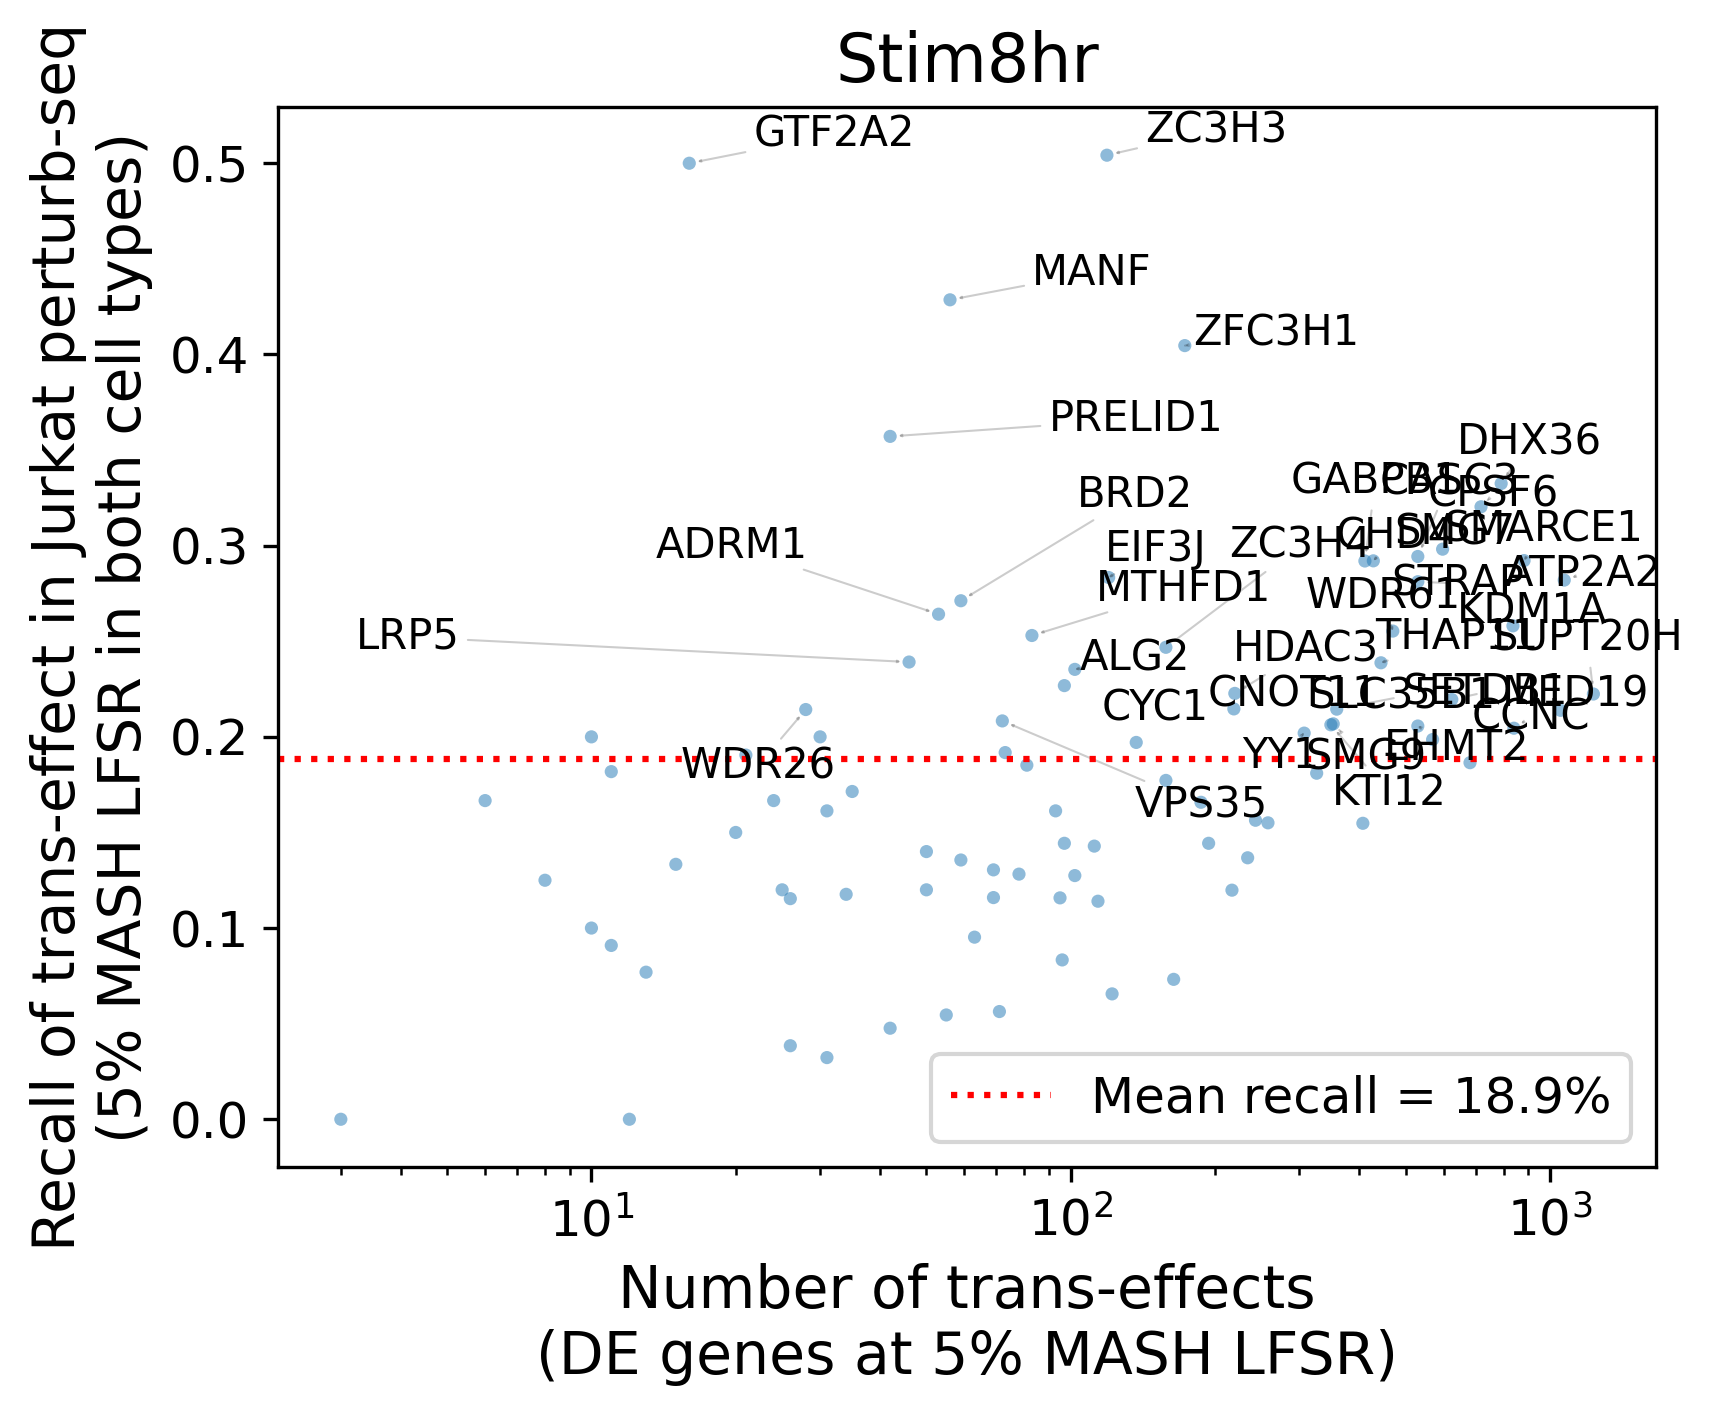

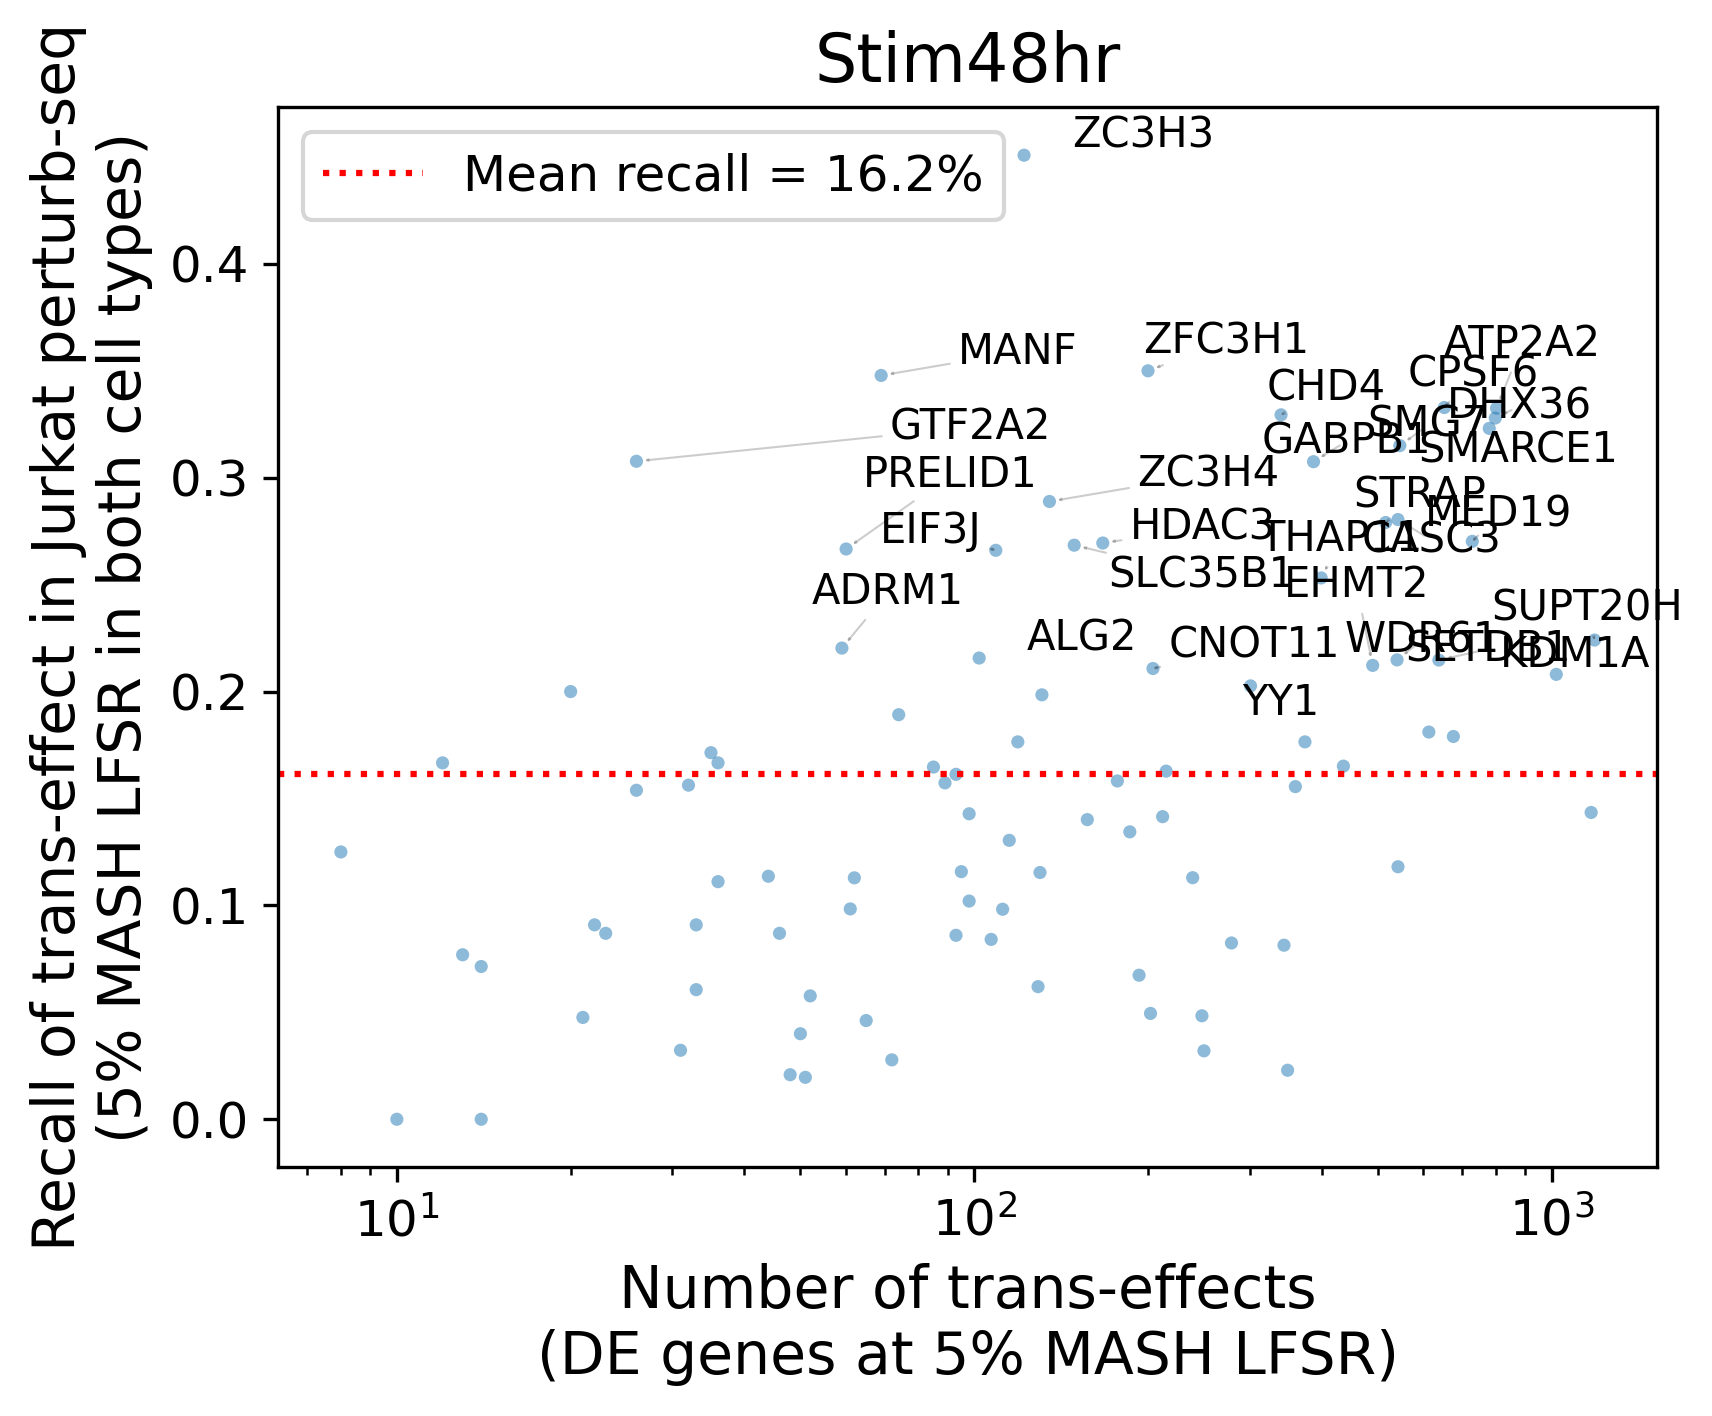

In [52]:
for c in ['Rest', 'Stim8hr', 'Stim48hr']:
    # Compute recall of DE genes with Jurkat
    signif_df = (wide_signif_res_df[['Jurkat', c]]
        .groupby('target_contrast')
        .apply(lambda x: pd.Series({
            'Jurkat_repl': ((~x['Jurkat'].isna()) & (~x[c].isna())).sum(),
            'n_signif': (~x[c].isna()).sum()
        })))
    signif_df = signif_df.sort_values('n_signif', ascending=False)
    tot_de = signif_df[signif_df['n_signif'] > 1]['n_signif']
    recall_jurkat = signif_df[signif_df['n_signif'] > 1]['Jurkat_repl']/signif_df[signif_df['n_signif'] > 1]['n_signif']
    mean_recall = recall_jurkat.mean()

    plt.figure(figsize=(6,5))
    sns.scatterplot(x=tot_de, y=recall_jurkat, edgecolor='none', alpha=0.5, s=10)

    # Add mean recall line
    plt.axhline(y=mean_recall, color='red', linestyle=':', label=f'Mean recall = {(mean_recall*100):.1f}%')

    # Add annotations for genes with high recall and high effects
    annot_df = signif_df[(signif_df['n_signif'] > 10) & (signif_df['Jurkat_repl']/signif_df['n_signif'] > 0.5)]
    
    texts = [plt.annotate(idx, xy=(row['n_signif'], row['Jurkat_repl']/row['n_signif']),fontsize=10) for idx, row in annot_df.iterrows()]

    # Use adjustText to prevent text overlaps
    from adjustText import adjust_text
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black', lw=0.5, alpha=0.2))

    plt.xscale('log')
    plt.xlabel('Number of trans-effects\n(DE genes at 5% MASH LFSR)', fontsize=14)
    plt.ylabel('Recall of trans-effect in Jurkat perturb-seq\n(5% MASH LFSR in both cell types)', fontsize=14)
    plt.title(f'{c}', fontsize=16)
    plt.legend(fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.tight_layout()
    plt.savefig(f'./results/recall_scatterplot.{c}.pdf')
    plt.savefig(f'./results/recall_scatterplot.{c}.png')
    plt.show()

## Compare effect size

In [16]:
# Keep targets with at least some significant effect in all datasets
n_de_genes_ct = signif_res_df.value_counts(['cell_type', 'target_contrast']).reset_index().pivot(columns='cell_type', index='target_contrast', values='count').fillna(0)
keep_targets = n_de_genes_ct[n_de_genes_ct.gt(2).all(axis=1)].index.tolist()

In [17]:
len(keep_targets)

82

In [18]:
jurkat_de_compare = all_res_df[all_res_df.cell_type == 'Jurkat'].pivot(columns='target_contrast', index='gene_name', values="PosteriorMean")
rest_de_compare = all_res_df[all_res_df.cell_type == 'Rest'].pivot(columns='target_contrast', index='gene_name', values="PosteriorMean")
stim_de_compare = all_res_df[all_res_df.cell_type == 'Stim8hr'].pivot(columns='target_contrast', index='gene_name', values="PosteriorMean")
stim48_de_compare = all_res_df[all_res_df.cell_type == 'Stim48hr'].pivot(columns='target_contrast', index='gene_name', values="PosteriorMean")

In [19]:
jurkat_de_compare = jurkat_de_compare.mask(jurkat_de_compare.index.values[:, None] == jurkat_de_compare.columns.values).fillna(0)[keep_targets]
rest_de_compare = rest_de_compare.mask(rest_de_compare.index.values[:, None] == rest_de_compare.columns.values).fillna(0)[keep_targets]
stim_de_compare = stim_de_compare.mask(jurkat_de_compare.index.values[:, None] == stim_de_compare.columns.values).fillna(0)[keep_targets]
stim48_de_compare = stim48_de_compare.mask(jurkat_de_compare.index.values[:, None] == stim48_de_compare.columns.values).fillna(0)[keep_targets]

In [46]:
# Define the comparisons we want to make
comparisons = [
    ('Jurkat vs CD4+T (Rest)', jurkat_de_compare, rest_de_compare),
    ('Jurkat vs CD4+T (Stim 8hr)', jurkat_de_compare, stim_de_compare),
    ('Jurkat vs CD4+T (Stim 48hr)', jurkat_de_compare, stim48_de_compare),
    ('CD4+T (Stim 8hr) vs CD4+T (Rest)', stim_de_compare, rest_de_compare),
    ('CD4+T (Stim 8hr) vs CD4+T (Stim 48hr)', stim_de_compare, stim48_de_compare),
    ('CD4+T (Stim 48hr) vs CD4+T (Rest)', stim48_de_compare, rest_de_compare)
]

comparison_results = {}

for comparison_name, df1, df2 in comparisons:
    results_df = pd.DataFrame(columns=['Perturbation', 'pearson_r', 'pearson_pval', 
                                      'random_r1', 'random_r2', 'random_r3'])
    
    for perturb in df1.columns:
        values1 = df1[perturb]
        values2 = df2[perturb]
        
        # Calculate correlation for the same perturbation
        corr = scipy.stats.pearsonr(values1, values2)
        
        # Calculate random correlations (shuffling column labels 3 times)
        random_rs = []
        for _ in range(3):
            random_perturb = np.random.choice(df1.columns)
            random_values = df2[random_perturb]
            random_corr = scipy.stats.pearsonr(values1, random_values)
            random_rs.append(random_corr.statistic)
        
        new_row = pd.DataFrame({
            'Perturbation': [perturb],
            'pearson_r': [corr.statistic],
            'pearson_pval': [corr.pvalue],
            'random_r1': [random_rs[0]],
            'random_r2': [random_rs[1]],
            'random_r3': [random_rs[2]]
        })
        results_df = pd.concat([results_df, new_row], ignore_index=True)
    
    
    results_df = results_df.sort_values('pearson_r', ascending=False)
    comparison_results[comparison_name] = results_df

correlation_results = pd.concat([v.assign(comparison=k) for k,v in comparison_results.items()])

/tmp/ipykernel_938640/1337791158.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row], ignore_index=True)
/tmp/ipykernel_938640/1337791158.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row], ignore_index=True)
/tmp/ipykernel_938640/1337791158.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or a

In [50]:
correlation_results.groupby('comparison')['pearson_r'].median()

comparison
CD4+T (Stim 48hr) vs CD4+T (Rest)        0.874721
CD4+T (Stim 8hr) vs CD4+T (Rest)         0.954983
CD4+T (Stim 8hr) vs CD4+T (Stim 48hr)    0.896337
Jurkat vs CD4+T (Rest)                   0.892713
Jurkat vs CD4+T (Stim 48hr)              0.814565
Jurkat vs CD4+T (Stim 8hr)               0.866016
Name: pearson_r, dtype: float64

In [21]:
correlation_results = pd.concat([v.assign(comparison=k) for k,v in comparison_results.items()])

In [48]:
print("Jurkat comparisons median:", correlation_results[correlation_results.comparison.str.contains('Jurkat')].pearson_r.mean())
print("CD4 comparisons median:", correlation_results[~correlation_results.comparison.str.contains('Jurkat')].pearson_r.mean())

Jurkat comparisons median: 0.8249321574467269
CD4 comparisons median: 0.893116022235165


In [23]:
# Read cross-donor correlation between CD4+T
datadir = '/mnt/oak/users/emma/data/GWT/'
experiment_name = 'CD4i_final'
all_correlations = pd.read_csv('../results/DE_donor_robustness_correlation.csv', index_col=0)
donor_correlation_summary = pd.read_csv('../results/DE_donor_robustness_correlation_summary.csv', index_col=0)

cross_donor_df = donor_correlation_summary[['target_name', 'condition', 'donor_correlation_mean']].rename(columns={'target_name':'Perturbation'})

In [27]:
correlation_results

,Perturbation,pearson_r,pearson_pval,random_r1,random_r2,random_r3,comparison,condition,donor_correlation_mean,n_degs_Jurkat,n_degs_Rest,n_degs_Stim48hr,n_degs_Stim8hr
0,SMG7,0.974969,0.000000e+00,0.015157,0.033832,0.305277,Jurkat vs CD4+T (Rest),Rest,0.378292,179.0,574.0,546.0,597.0
1,NDUFAF3,0.972903,0.000000e+00,0.068619,0.035616,0.039122,Jurkat vs CD4+T (Rest),Rest,NaN,8.0,65.0,349.0,59.0
2,CD2BP2,0.970349,0.000000e+00,-0.020738,-0.046487,-0.182586,Jurkat vs CD4+T (Rest),Rest,0.384136,4.0,33.0,50.0,34.0
3,GABPB1,0.968418,0.000000e+00,-0.048079,0.029776,0.061664,Jurkat vs CD4+T (Rest),Rest,0.527871,122.0,384.0,387.0,411.0
4,CASC3,0.967424,0.000000e+00,-0.049047,0.173971,-0.074918,Jurkat vs CD4+T (Rest),Rest,0.578596,156.0,511.0,542.0,530.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,HSPD1,0.530105,8.875752e-274,0.001530,0.043190,-0.007423,Jurkat vs CD4+T (Stim 48hr),Stim48hr,NaN,3.0,11.0,12.0,10.0
242,CLOCK,0.498228,4.536235e-237,0.046521,0.019199,0.031080,Jurkat vs CD4+T (Stim 48hr),Stim48hr,NaN,3.0,13.0,21.0,13.0
243,FUNDC2,0.477619,2.491285e-215,0.017693,0.062916,-0.028046,Jurkat vs CD4+T (Stim 48hr),Stim48hr,NaN,10.0,26.0,36.0,35.0
244,TPP2,0.441257,1.977808e-180,-0.001165,0.028128,0.005421,Jurkat vs CD4+T (Stim 48hr),Stim48hr,NaN,3.0,15.0,23.0,11.0


In [ ]:
correlation_results['comparison']

array(['Jurkat vs CD4+T (Rest)', 'Jurkat vs CD4+T (Stim 8hr)',
       'Jurkat vs CD4+T (Stim 48hr)'], dtype=object)

<Axes: >

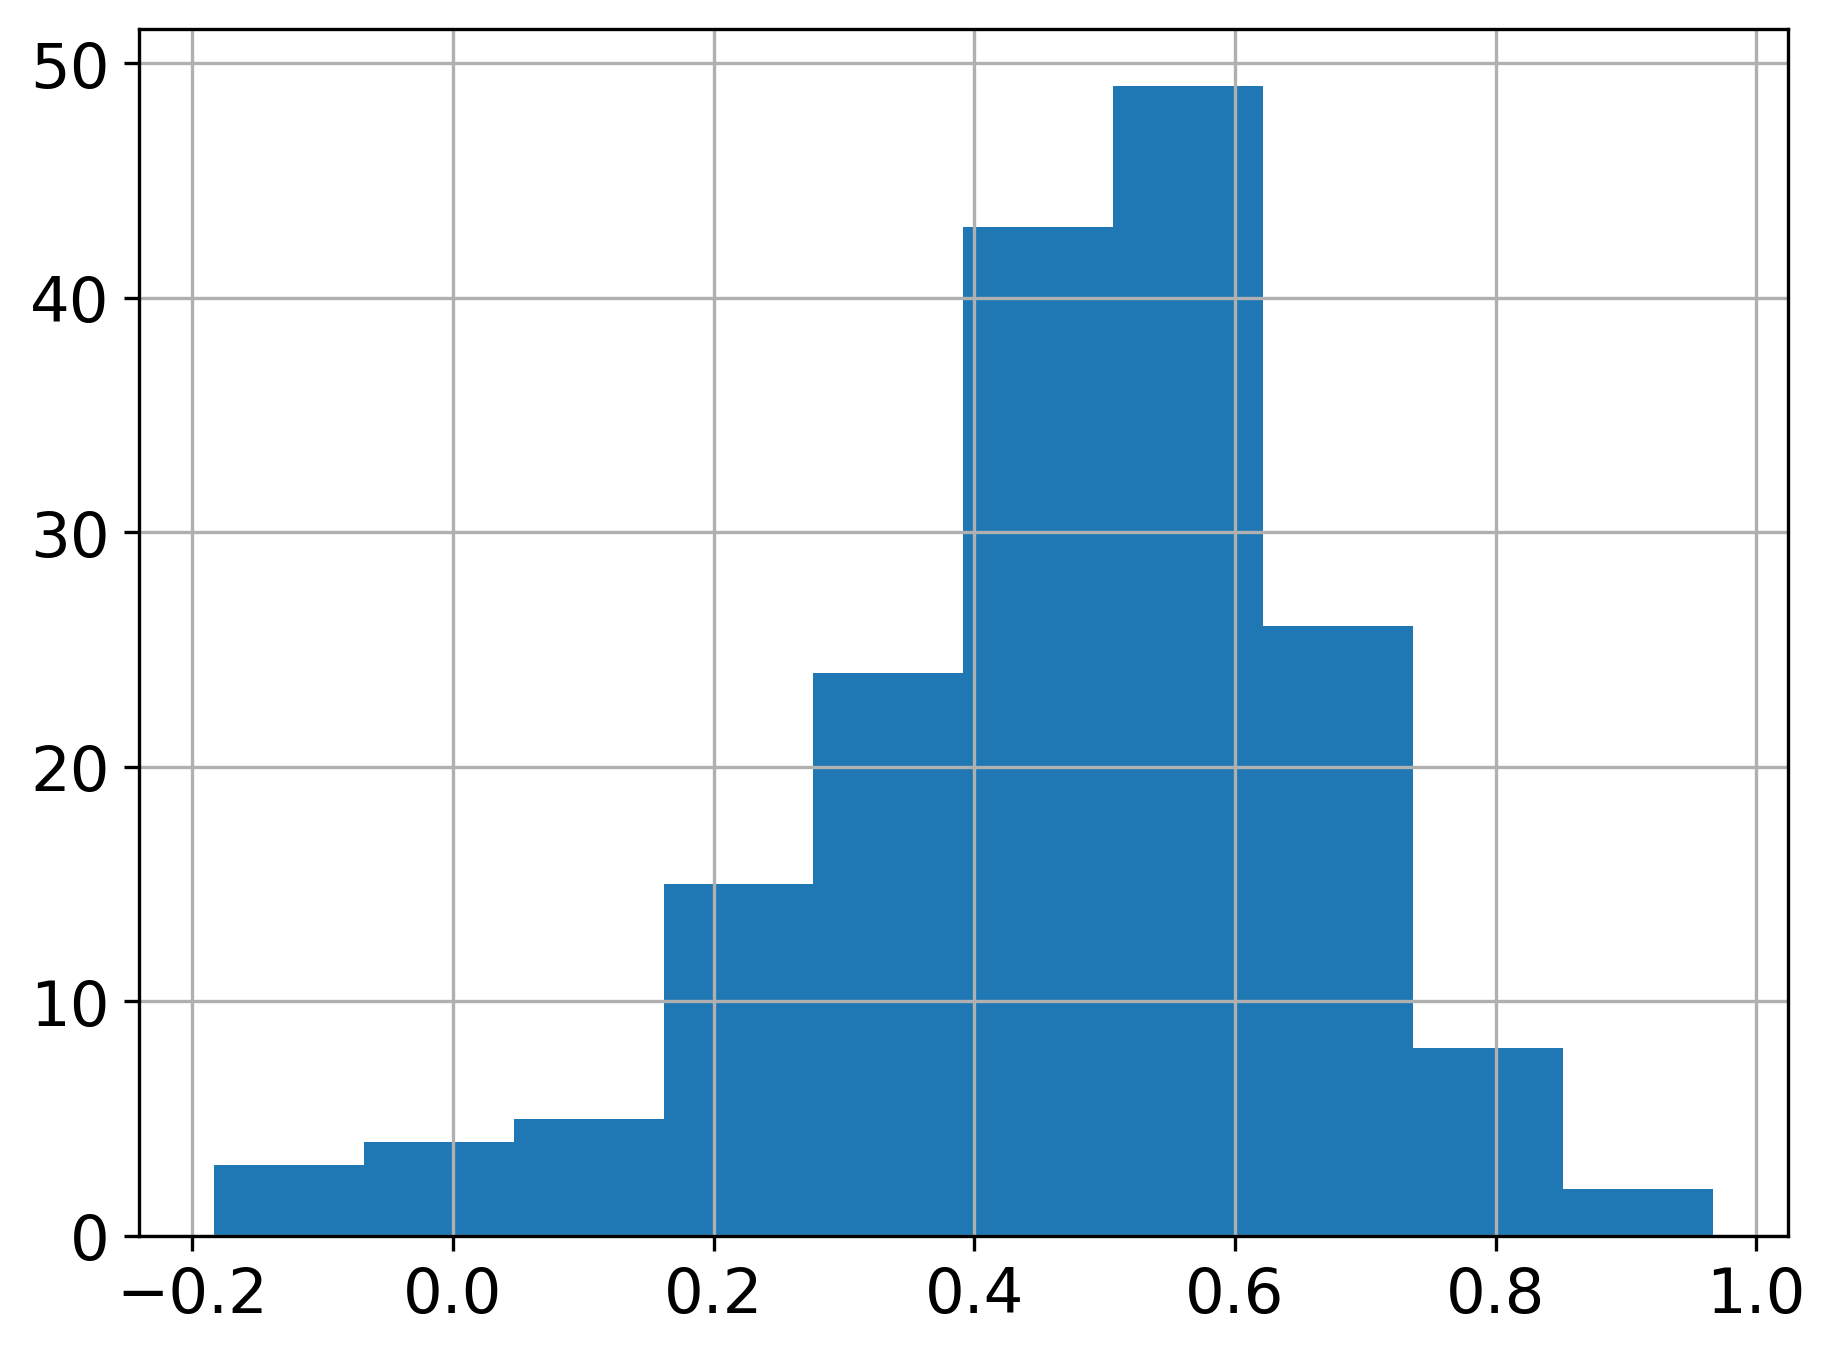

In [42]:
jurkat_correlation_results.donor_correlation_mean.hist()

/tmp/ipykernel_938640/3900902661.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig('./results/Jurkat_effect_size_correlation.pdf')
/tmp/ipykernel_938640/3900902661.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig('./results/Jurkat_effect_size_correlation.png')
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


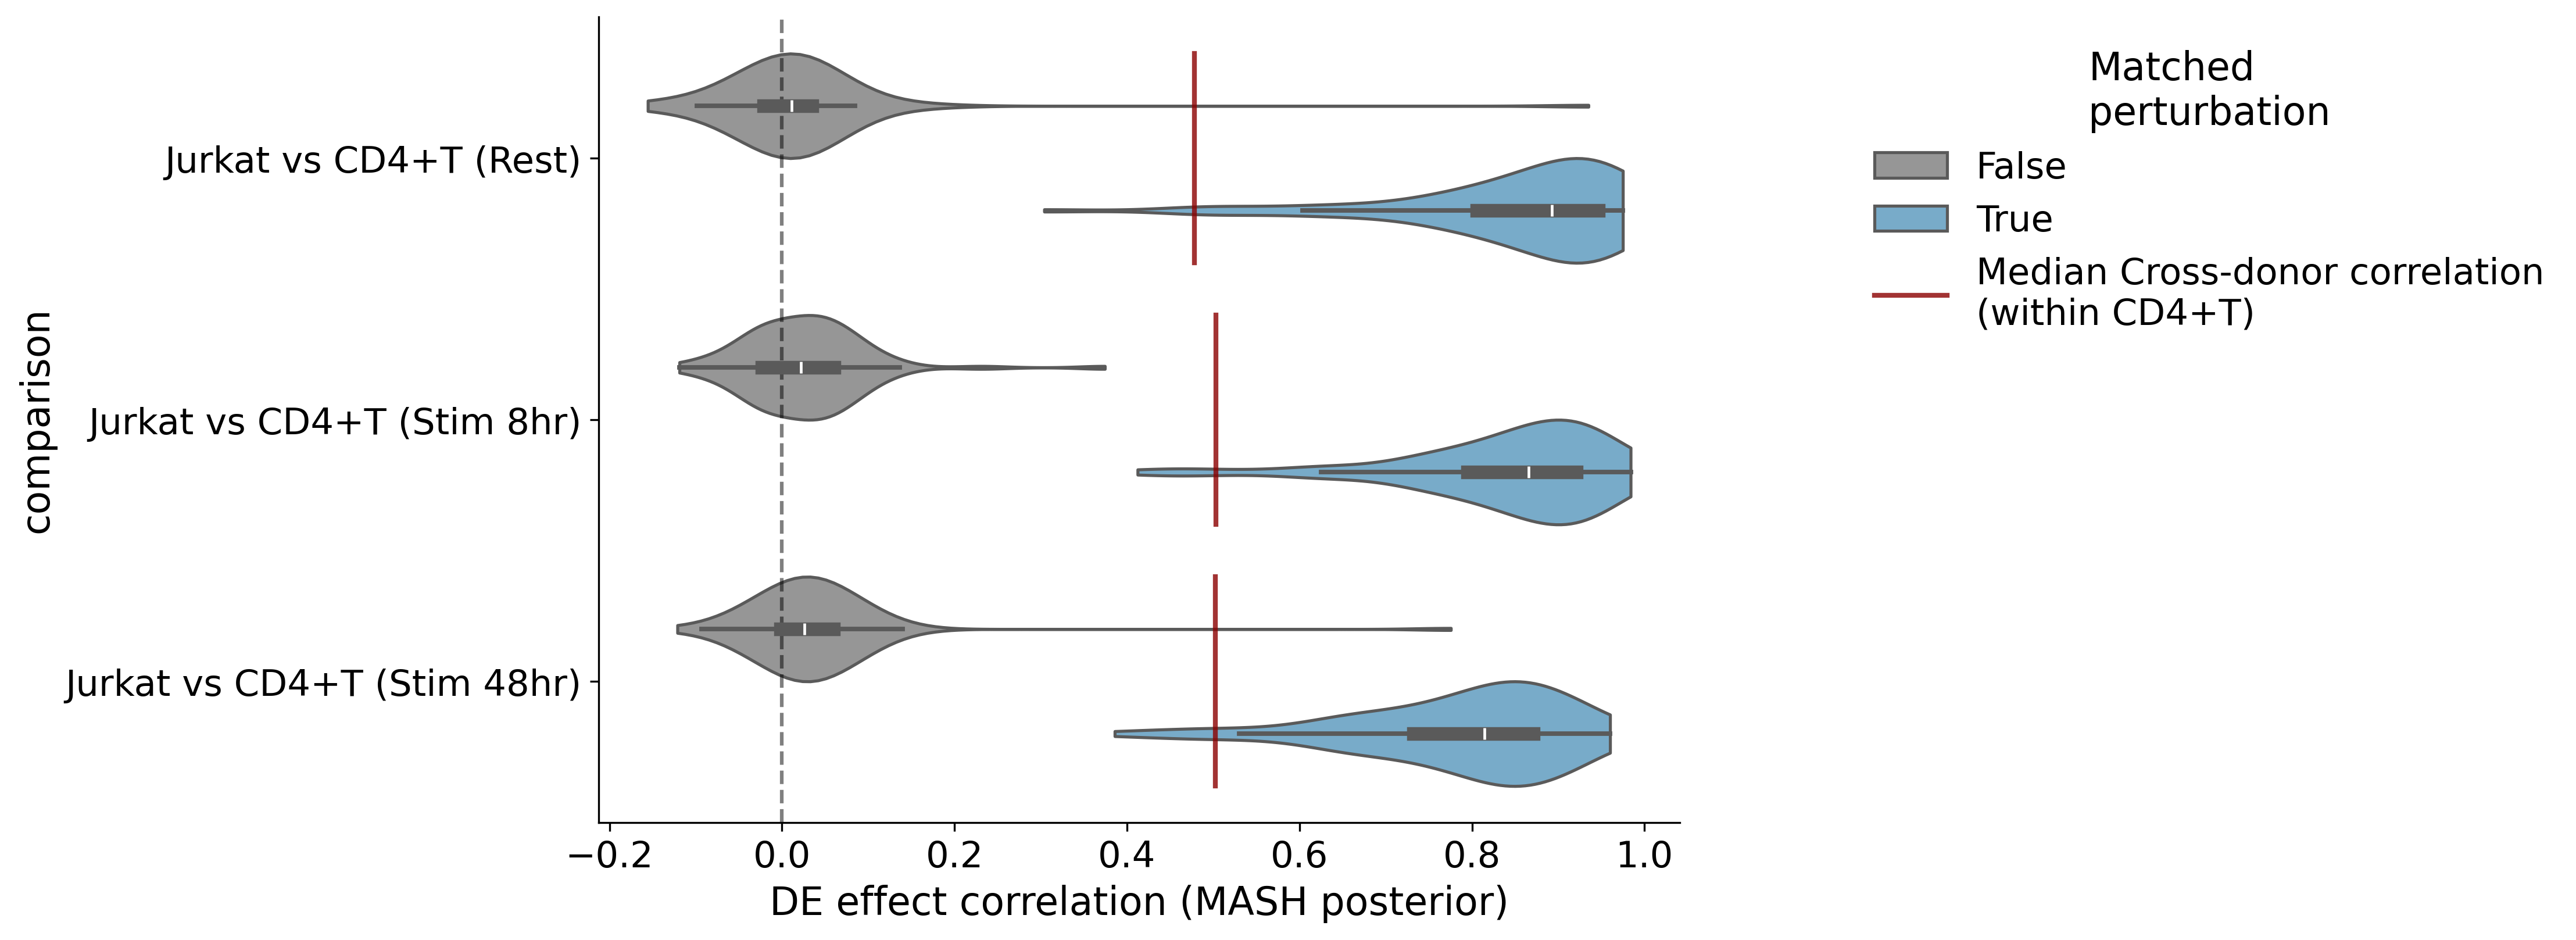

In [24]:
jurkat_correlation_results = correlation_results[correlation_results.comparison.str.contains('Jurkat')].copy()
jurkat_correlation_results['condition'] = jurkat_correlation_results['comparison'].str.split("(").str[1].str.replace(")", '').str.replace(" ", '')

jurkat_correlation_results = pd.merge(jurkat_correlation_results, cross_donor_df[cross_donor_df.Perturbation.isin(jurkat_correlation_results.Perturbation)], how='left')

pl_n_de_genes_ct = n_de_genes_ct.copy()
pl_n_de_genes_ct.columns = [f'n_degs_{x}' for x in pl_n_de_genes_ct.columns]
pl_n_de_genes_ct = pl_n_de_genes_ct.reset_index().rename(columns={'target_contrast': 'Perturbation'})

correlation_results = pd.merge(jurkat_correlation_results, pl_n_de_genes_ct, how='left')

pl_correlation_df = jurkat_correlation_results[['Perturbation', 'pearson_r', 'random_r1', 'comparison']].melt(id_vars=['Perturbation', 'comparison'], value_name='r', var_name='perturbation_pair')
pl_correlation_df['perturbation_pair'] = np.where(pl_correlation_df['perturbation_pair'] == 'pearson_r', True, False)

matched_target_palette = palettes['matched_targets']
plt.figure(figsize=(8,6))
ax = plt.gca()
sns.violinplot(data=pl_correlation_df, y='comparison', x='r', hue='perturbation_pair', cut=0, density_norm='width', palette=matched_target_palette);

plt.axvline(0, linestyle='--', color='black', zorder=1, alpha=0.5)

# Show one line for cross-donor correlation per condition
merged_cross_donor = correlation_results.groupby(['condition', 'comparison'])[['donor_correlation_mean']].median().reset_index()
y_ticks = list(pl_correlation_df['comparison'].unique())
for i, row in merged_cross_donor.iterrows():
    if row['comparison'] in y_ticks:
        y_idx = y_ticks.index(row['comparison'])
        plt.plot(
            [row['donor_correlation_mean'], row['donor_correlation_mean']],
            [y_idx-0.4, y_idx+0.4],
            color='darkred', alpha=0.8, linewidth=2, zorder=10,
            label=f"Median Cross-donor correlation\n(within CD4+T)" if i == 0 else None
        )

plt.legend(bbox_to_anchor=(1.15, 1), loc='upper left', title='Matched\nperturbation', frameon=False)
sns.despine()
plt.xlabel('DE effect correlation (MASH posterior)')
plt.savefig('./results/Jurkat_effect_size_correlation.pdf')
plt.savefig('./results/Jurkat_effect_size_correlation.png')

In [ ]:
correlation_results = pd.concat([v.assign(comparison=k) for k,v in comparison_results.items()])

# Create figure with 3 subplots in one row
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Plot each comparison in its own subplot
for i, comparison in enumerate(correlation_results.comparison.unique()):
    ax = axes[i]
    mask = correlation_results['comparison'] == comparison
    
    # Plot random distributions
    for col in ['random_r1', 'random_r2', 'random_r3']:
        data = correlation_results[mask][col]
        sns.kdeplot(
            data=data,
            ax=ax,
            color='#7f7f7f',
            linewidth=1,
            alpha=0.3,
            label='Unmatched perturbation' if col == 'random_r1' else '_nolegend_',
            bw_adjust=0.5,
            common_norm=True,
            clip=(data.min(), data.max())
        )

    # Plot main distribution  
    data = correlation_results[mask]['pearson_r']
    sns.kdeplot(
        data=data,
        ax=ax,
        color='#8B0000',
        linewidth=3,
        label='Matched perturbation',
        bw_adjust=0.5,
        common_norm=False,
        clip=(data.min(), data.max())
    )
    # Add vertical lines
    median = correlation_results[mask]['pearson_r'].median()
    ax.axvline(median, color='#8B0000', linestyle='dashed', linewidth=2, label=f'Median')
    ax.axvline(0, color='#7f7f7f', linestyle='dotted', linewidth=2)

    # Styling
    ax.set_xlabel('DE effect correlation\n(MASH posterior)', fontsize=16)
    if i == 0:
        ax.set_ylabel('Density', fontsize=16)
    else:
        ax.set_ylabel('', fontsize=12)
    ax.set_title(comparison.replace('_', ' '), fontsize=16)
    if i == 3:
        ax.legend(fontsize=16, bbox_to_anchor=(1.1, 1), frameon=False)
    ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig('Jurkat_vs_CD4_MASH_correlation.png')
fig.savefig('Jurkat_vs_CD4_MASH_correlation.pdf')
fig.show()

In [ ]:
import gseapy as gp

def parse_gene_sets(filename):
   gene_sets = {}
   with open(filename, 'r') as f:
       for line in f:
           terms = line.strip().split('\t')
           gene_sets[terms[0]] = terms[2:]
   return gene_sets

OAKPATH = '/mnt/oak/'
KEGG_sets = parse_gene_sets(f'{OAKPATH}/users/emma/data//KEGG_2019_Human.txt')
GO_BP_sets = parse_gene_sets(f'{OAKPATH}/users/emma/data/GO_Biological_Process_2023.txt')
GENESETS = {**GO_BP_sets, **KEGG_sets}

# Top correlations in Jurkat comparison
top_20_threshold = correlation_results[correlation_results.comparison.str.contains('Jurkat')]['pearson_r'].quantile(0.8)
correlated_gs = correlation_results[correlation_results.comparison.str.contains('Jurkat') & 
                                (correlation_results['pearson_r'] >= top_20_threshold)].Perturbation.unique()
correlated_gs = correlated_gs.tolist()
all_gs = correlation_results.Perturbation.unique().tolist()
enr = gp.enrichr(gene_list=correlated_gs,
                gene_sets=GENESETS,
                organism='Human', 
                cutoff=1,
                background=all_gs,
                outdir=f'results/test_enrichr/Jurkat_top_correlations/',
                no_plot=True
                )

jurkat_high_corr_terms = enr.results[['Term', 'P-value', 'Adjusted P-value', 'Genes']].sort_values('Adjusted P-value')
jurkat_high_corr_terms.head()

In [ ]:
jurkat_correlation_results = correlation_results[correlation_results.comparison.str.contains('Jurkat')].copy()
jurkat_correlation_results['condition'] = jurkat_correlation_results['comparison'].str.split("(").str[1].str.replace(")", '').str.replace(" ", '')

jurkat_correlation_results = pd.merge(jurkat_correlation_results, cross_donor_df[cross_donor_df.Perturbation.isin(jurkat_correlation_results.Perturbation)], how='left')

pl_n_de_genes_ct = n_de_genes_ct.copy()
pl_n_de_genes_ct.columns = [f'n_degs_{x}' for x in pl_n_de_genes_ct.columns]
pl_n_de_genes_ct = pl_n_de_genes_ct.reset_index().rename(columns={'target_contrast': 'Perturbation'})

correlation_results = pd.merge(jurkat_correlation_results, pl_n_de_genes_ct, how='left')

pl_correlation_df = jurkat_correlation_results[['Perturbation', 'pearson_r', 'random_r1', 'comparison']].melt(id_vars=['Perturbation', 'comparison'], value_name='r', var_name='perturbation_pair')
pl_correlation_df['perturbation_pair'] = np.where(pl_correlation_df['perturbation_pair'] == 'pearson_r', True, False)

matched_target_palette = palettes['matched_targets']
plt.figure(figsize=(8,6))
ax = plt.gca()
sns.violinplot(data=pl_correlation_df, y='comparison', x='r', hue='perturbation_pair', cut=0, density_norm='width', palette=matched_target_palette);
plt.axvspan(top_20_threshold, 1, ymin=0.03, ymax=0.97, facecolor='none', edgecolor='red', linestyle=':', alpha=1, linewidth=2)

plt.axvline(0, linestyle='--', color='black', zorder=1, alpha=0.5)

# Show one line for cross-donor correlation per condition
merged_cross_donor = correlation_results.groupby(['condition', 'comparison'])[['donor_correlation_mean']].median().reset_index()
y_ticks = list(pl_correlation_df['comparison'].unique())
for i, row in merged_cross_donor.iterrows():
    if row['comparison'] in y_ticks:
        y_idx = y_ticks.index(row['comparison'])
        plt.plot(
            [row['donor_correlation_mean'], row['donor_correlation_mean']],
            [y_idx-0.4, y_idx+0.4],
            color='darkred', alpha=0.8, linewidth=2, zorder=10,
            label=f"Median Cross-donor correlation\n(within CD4+T)" if i == 0 else None
        )

plt.legend(loc='upper center', bbox_to_anchor=(0.3, 1.3), title='Matched perturbation', frameon=False, ncols=2)
sns.despine()
plt.xlabel('DE effect correlation (MASH posterior)')
plt.tight_layout()
plt.savefig('./results/Jurkat_effect_size_correlation.pdf')
plt.savefig('./results/Jurkat_effect_size_correlation.png')

In [ ]:
signif_terms = jurkat_high_corr_terms[jurkat_high_corr_terms['Adjusted P-value'] < 0.1].copy()
signif_terms = signif_terms.sort_values('Adjusted P-value', ascending=False)
signif_terms['-log10(adj P)'] = -np.log10(signif_terms['Adjusted P-value'])

signif_terms['Term'] = signif_terms['Term'].str.replace('Regulation', 'Reg.')
signif_terms['Term'] = signif_terms['Term'].str.replace('Positive', 'Pos.')
signif_terms['Term'] = signif_terms['Term'].str.replace('Negative', 'Neg.')
signif_terms['Term'] = np.where(signif_terms['Term'].str.contains(','), signif_terms['Term'].str.split(',').str[0] + ' (GO:' + signif_terms['Term'].str.split(',').str[1].str.split(' \(GO:').str[1],  signif_terms['Term'])

plt.figure(figsize=(8, 6))
ax = plt.gca()

bars = plt.barh(range(len(signif_terms)), signif_terms['-log10(adj P)'], color='grey')

plt.yticks(range(len(signif_terms)), signif_terms['Term'], fontsize=10)
plt.xlabel('-log10(Adjusted P-value)')
plt.axvline(x=1, color='black', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('High Jurkat correlation perturbations', pad=20, fontsize=14)

fig = plt.gcf()
fig.patch.set_edgecolor('red')
fig.patch.set_linewidth(3)
fig.patch.set_linestyle(':')

plt.tight_layout()
plt.savefig('./results/Jurkat_top_corr_GO_terms.pdf')
plt.savefig('./results/Jurkat_top_corr_GO_terms.png')